# Sales Forecasting Across Multiple Retail Stores (Rossmann Pharmaceuticals)

# Project Introduction

### Objective

To develop an end-to-end Machine Learning and Deep Learning sales forecasting system that predicts store sales up to 6 weeks in advance. 

### Datasets

* train.csv
* test.csv
* store.csv


## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

from scipy import stats

## Load Data

In [2]:
train = pd.read_csv("train.csv",low_memory = False)
test = pd.read_csv("test.csv",low_memory = False)
store = pd.read_csv("store.csv",low_memory = False)

In [3]:
train.shape, test.shape, store.shape

((1017209, 9), (41088, 8), (1115, 10))

Observation

Train: 1,017,209 rows
Test: 41,088 rows
Store: 1,115 rows

## Merge Store Information

##### Train Dataset (Merge Store with Train dataset)

In [4]:
df_train = train.merge(store, on="Store", how="left")

#### Test Dataset (Merge Store with Test dataset)

In [5]:
df_test = test.merge(store, on="Store", how="left")

# Part -1 (EDA)

## Dataset Overview

In [6]:
df_train.head()


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
df_test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN


In [8]:
df_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [9]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Id                         41088 non-null  int64  
 1   Store                      41088 non-null  int64  
 2   DayOfWeek                  41088 non-null  int64  
 3   Date                       41088 non-null  object 
 4   Open                       41077 non-null  float64
 5   Promo                      41088 non-null  int64  
 6   StateHoliday               41088 non-null  object 
 7   SchoolHoliday              41088 non-null  int64  
 8   StoreType                  41088 non-null  object 
 9   Assortment                 41088 non-null  object 
 10  CompetitionDistance        40992 non-null  float64
 11  CompetitionOpenSinceMonth  25872 non-null  float64
 12  CompetitionOpenSinceYear   25872 non-null  float64
 13  Promo2                     41088 non-null  int

In [10]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.085652,7715.323700,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.222866,3.211832,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.690228,5.992644,1900.0,2006.0,2010.0,2013.0,2015.0


In [11]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,41088.0,20544.500000,11861.228267,1.0,10272.75,20544.5,30816.25,41088.0
Store,41088.0,555.899533,320.274496,1.0,279.75,553.5,832.25,1115.0
DayOfWeek,41088.0,3.979167,2.015481,1.0,2.00,4.0,6.00,7.0
Open,41077.0,0.854322,0.352787,0.0,1.00,1.0,1.00,1.0
Promo,41088.0,0.395833,0.489035,0.0,0.00,0.0,1.00,1.0
SchoolHoliday,41088.0,0.443487,0.496802,0.0,0.00,0.0,1.00,1.0
CompetitionDistance,40992.0,5088.583138,7225.487467,20.0,720.00,2425.0,6480.00,75860.0
CompetitionOpenSinceMonth,25872.0,7.035250,3.143015,1.0,4.00,7.0,9.00,12.0
CompetitionOpenSinceYear,25872.0,2008.641929,6.862400,1900.0,2006.00,2010.0,2012.00,2015.0
Promo2,41088.0,0.580607,0.493466,0.0,0.00,1.0,1.00,1.0


#### Interpretation

The dataset contains transactional, promotional, holiday, and competitor-related variables.

## Data Cleaning

### Missing Value Analysis

In [12]:
missing = pd.DataFrame({
    "Missing Count": df_train.isnull().sum(),
    "Missing %": round(df_train.isnull().mean()*100,2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
PromoInterval,508031,49.94
Promo2SinceYear,508031,49.94
Promo2SinceWeek,508031,49.94
CompetitionOpenSinceYear,323348,31.79
CompetitionOpenSinceMonth,323348,31.79
CompetitionDistance,2642,0.26
DayOfWeek,0,0.00
Promo2,0,0.00
Assortment,0,0.00
Store,0,0.00


In [13]:
missing = pd.DataFrame({
    "Missing Count": df_test.isnull().sum(),
    "Missing %": round(df_test.isnull().mean()*100,2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
PromoInterval,17232,41.94
Promo2SinceYear,17232,41.94
Promo2SinceWeek,17232,41.94
CompetitionOpenSinceYear,15216,37.03
CompetitionOpenSinceMonth,15216,37.03
CompetitionDistance,96,0.23
Open,11,0.03
Assortment,0,0.00
Promo2,0,0.00
Id,0,0.00


### Visualization (Missing Value Heatmap")

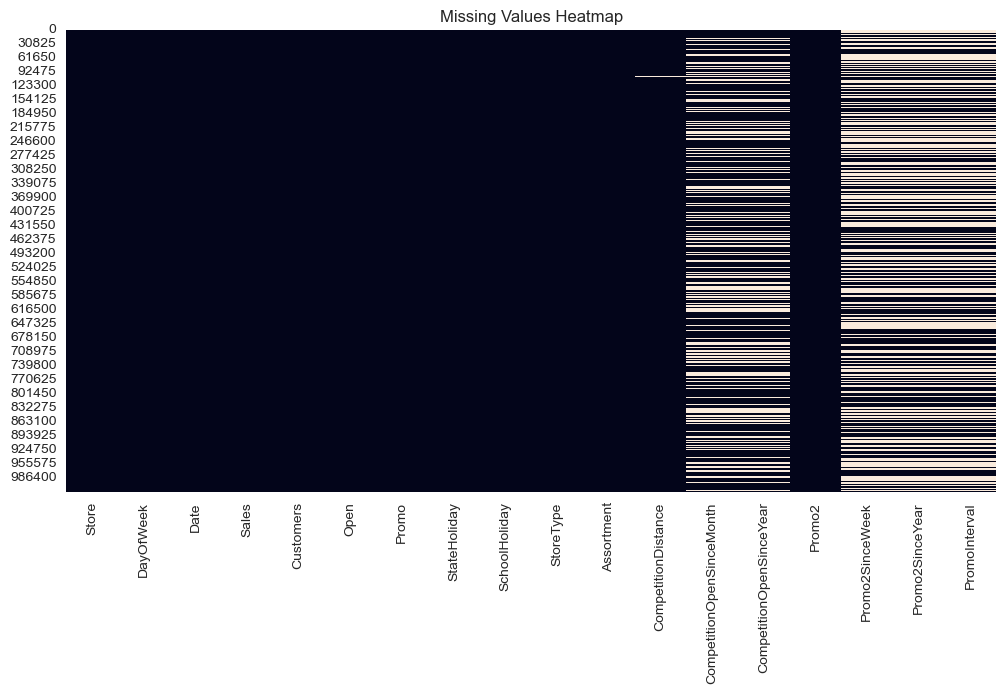

In [14]:
plt.figure(figsize=(12,6))
sns.heatmap(df_train.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

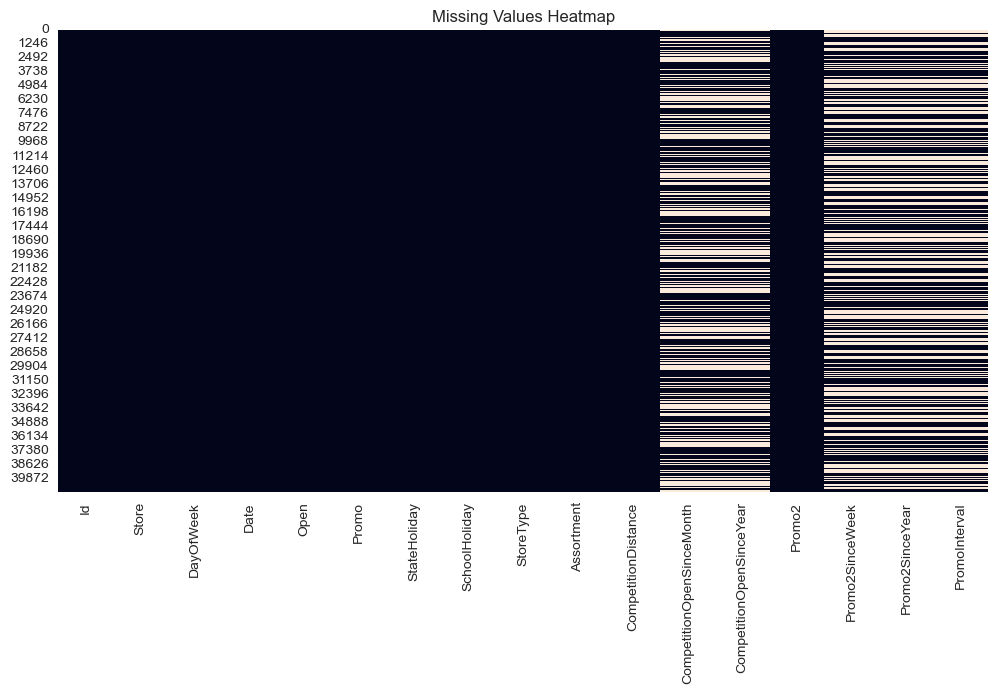

In [15]:
plt.figure(figsize=(12,6))
sns.heatmap(df_test.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### Findings

#### Major missing columns:

* PromoInterval
* Promo2SinceYear
* Promo2SinceWeek
* CompetitionOpenSinceMonth
* CompetitionOpenSinceYear

These missing values are expected because many stores never participated in Promo2 programs.

## Duplicate Analysis

In [16]:
duplicates = df_train.duplicated().sum()
duplicates

0

In [17]:
duplicates = df_test.duplicated().sum()
duplicates

0

### Finding

No duplicate rows found.

## Outlier Detection

### Sales

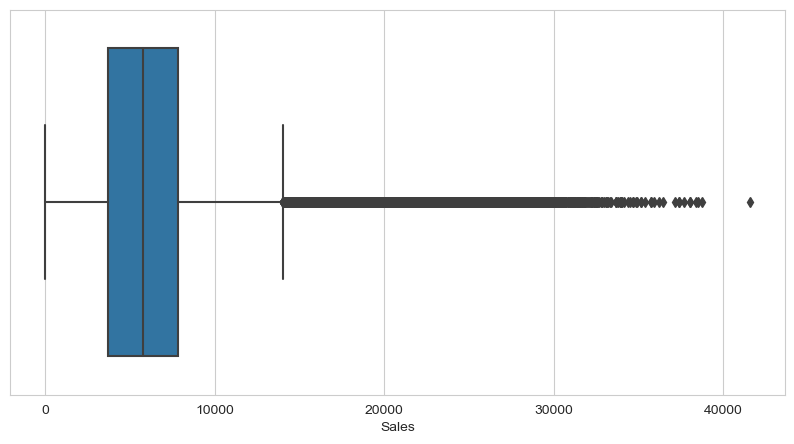

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_train["Sales"])
plt.show()

### Customers

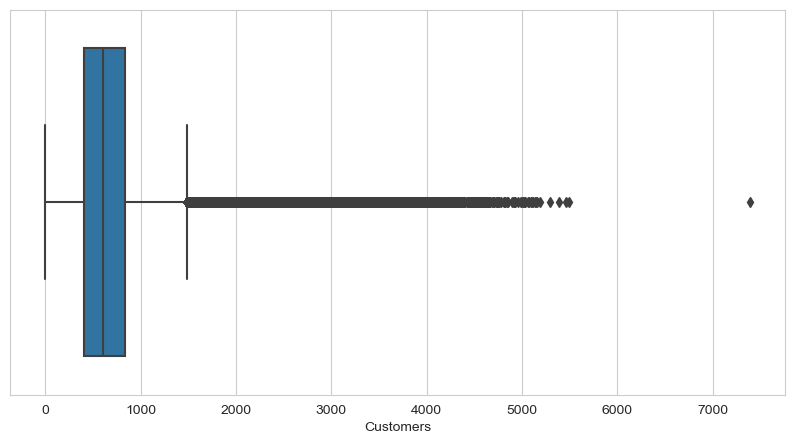

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_train["Customers"])
plt.show()

### Interpretation

Extreme sales spikes exist but correspond to real promotional periods and should not be removed blindly.

## Correlation Analysis

In [20]:
corr = df_train[["Sales","Customers","Promo"]].corr()
corr

,Sales,Customers,Promo
Sales,1.000000,0.894711,0.452345
Customers,0.894711,1.000000,0.316169
Promo,0.452345,0.316169,1.000000


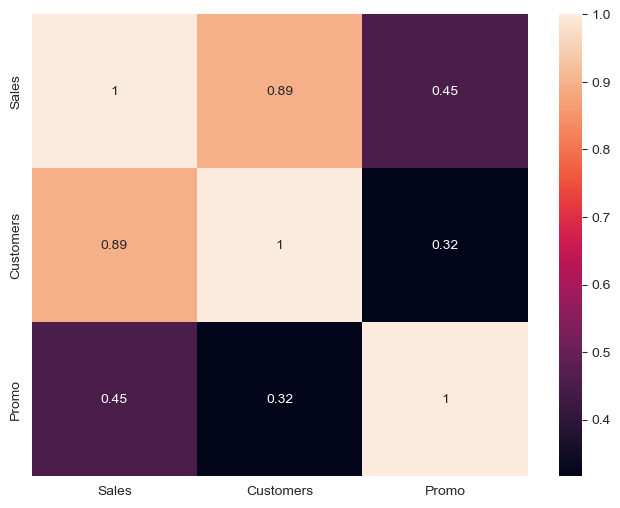

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

### Key Insight

Sales and Customers exhibit very strong correlation (~0.895).

## Customer Purchasing Behaviour Analysis

## Promotion Analysis

### Are promotions distributed similarly in train and test datasets?


##### Promotion Distribution Table

In [22]:
train_promo_dist = (
    train["Promo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

test_promo_dist = (
    test["Promo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

promo_distribution = pd.DataFrame({
    "Train (%)": train_promo_dist,
    "Test (%)": test_promo_dist
})

print(promo_distribution)

       Train (%)  Test (%)
Promo                     
0          61.85     60.42
1          38.15     39.58


#### Visualization

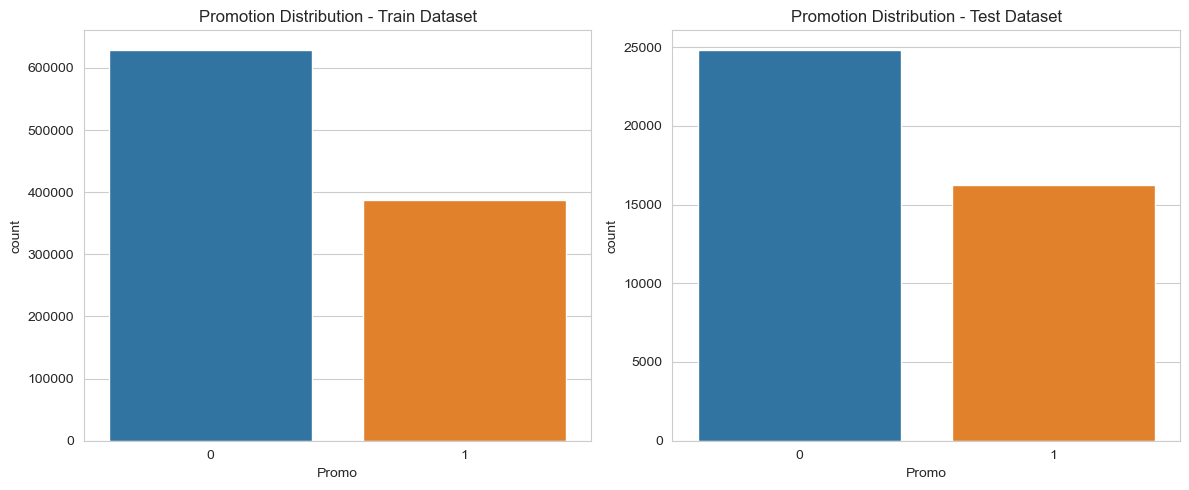

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(
    x="Promo",
    data=train,
    ax=ax[0]
)

ax[0].set_title("Promotion Distribution - Train Dataset")

sns.countplot(
    x="Promo",
    data=test,
    ax=ax[1]
)

ax[1].set_title("Promotion Distribution - Test Dataset")

plt.tight_layout()
plt.show()

##### Comparative Percentage Plot

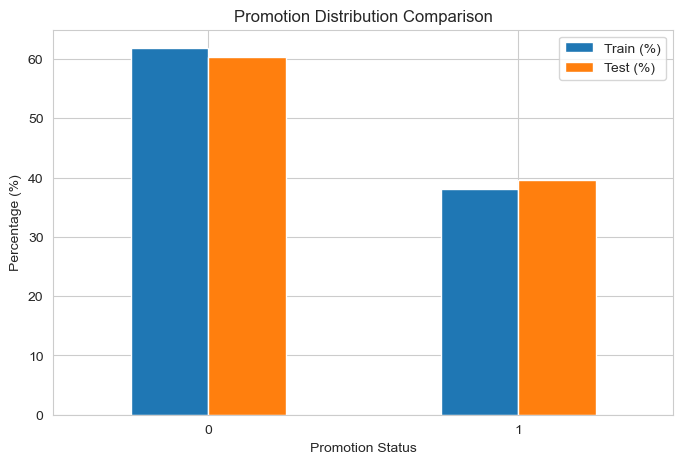

In [24]:
promo_distribution.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Promotion Distribution Comparison")
plt.ylabel("Percentage (%)")
plt.xlabel("Promotion Status")
plt.xticks(rotation=0)

plt.show()

#### Interpretation
Percentages of Promo=0 and Promo=1 in train & test datasets are similar , that means both datasets have comparable promotion distributions, which is desrirable for model generalization

### Do promotions increase sales?

#### Average Sales by Promotion Status

In [25]:
sales_by_promo = (
    train.groupby("Promo")["Sales"]
    .agg(["mean","median","sum","count"])
)

print(sales_by_promo)

              mean  median         sum   count
Promo                                         
0      4406.050805  4622.0  2771974337  629129
1      7991.152046  7553.0  3101206286  388080


#### Sales Comparison Plot

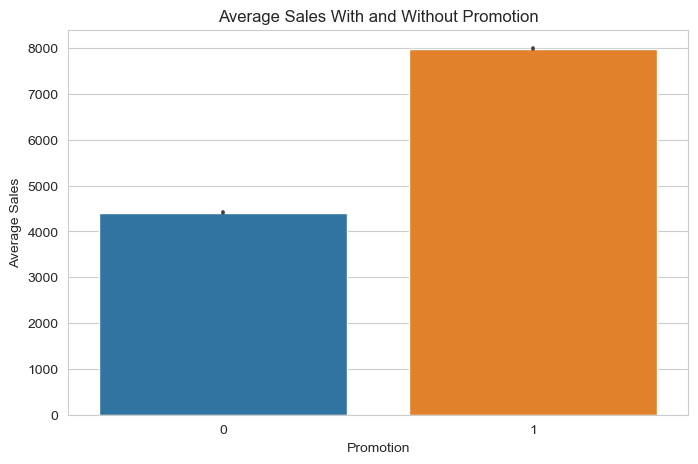

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Promo",
    y="Sales",
    data=train,
    estimator=np.mean
)

plt.title("Average Sales With and Without Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")

plt.show()

#### Boxplot

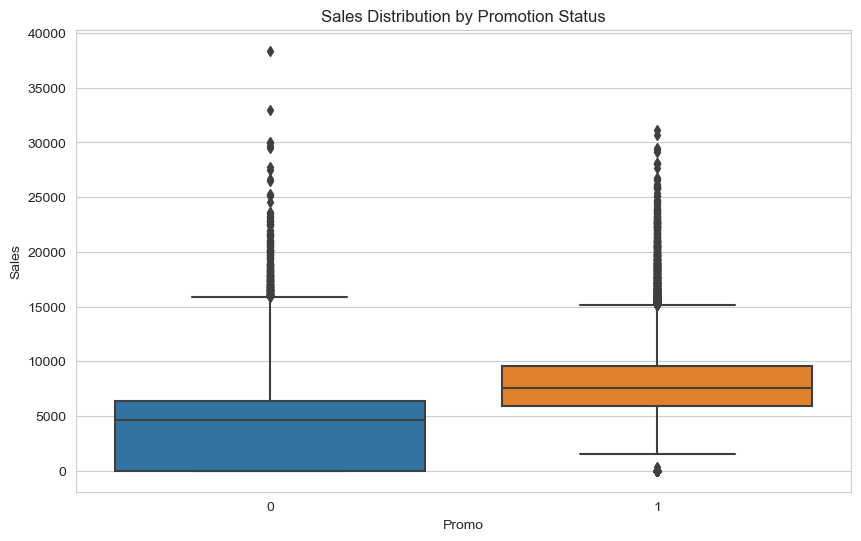

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Promo",
    y="Sales",
    data=train.sample(50000, random_state=42)
)

plt.title("Sales Distribution by Promotion Status")

plt.show()

#### Percentage Increase in Sales

In [28]:
sales_no_promo = train.loc[
    train["Promo"] == 0,
    "Sales"
].mean()

sales_with_promo = train.loc[
    train["Promo"] == 1,
    "Sales"
].mean()

increase_pct = (
    (sales_with_promo - sales_no_promo)
    / sales_no_promo
) * 100

print(f"Average Sales Without Promo : {sales_no_promo:,.2f}")
print(f"Average Sales With Promo    : {sales_with_promo:,.2f}")
print(f"Increase (%)               : {increase_pct:.2f}%")

Average Sales Without Promo : 4,406.05
Average Sales With Promo    : 7,991.15
Increase (%)               : 81.37%


#### Statistical Significance Test

In [29]:
from scipy.stats import ttest_ind

promo_sales = train.loc[
    train["Promo"] == 1,
    "Sales"
]

nonpromo_sales = train.loc[
    train["Promo"] == 0,
    "Sales"
]

t_stat, p_value = ttest_ind(
    promo_sales,
    nonpromo_sales,
    equal_var=False
)

print("T-Statistic :", t_stat)
print("P-Value     :", p_value)

T-Statistic : 512.3755316936371
P-Value     : 0.0


### Interpretation

In [30]:
if p_value < 0.05:
    print(
        "Promotions have a statistically significant effect on sales."
    )
else:
    print(
        "No statistically significant impact found."
    )

Promotions have a statistically significant effect on sales.


### Do promotions attract more customers?

#### Average Customers by Promotion Status

In [31]:
customers_by_promo = (
    train.groupby("Promo")["Customers"]
    .agg(["mean","median","sum","count"])
)

print(customers_by_promo)

             mean  median        sum   count
Promo                                       
0      517.823542   512.0  325777807  629129
1      820.098815   747.0  318263948  388080


#### Customer Comparison Plot

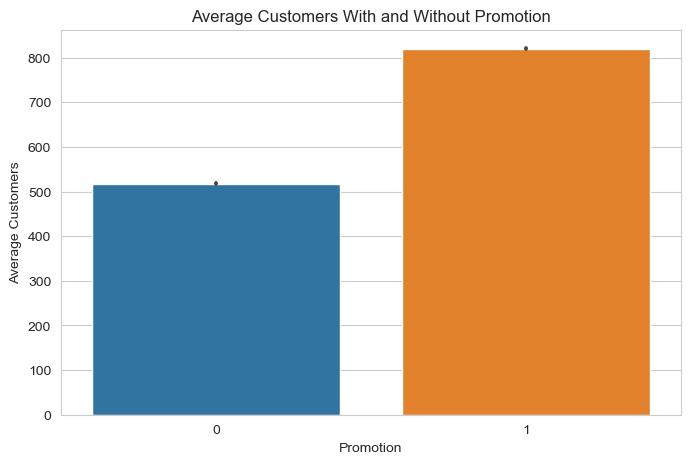

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Promo",
    y="Customers",
    data=train,
    estimator=np.mean
)

plt.title("Average Customers With and Without Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Customers")

plt.show()

#### Boxplot

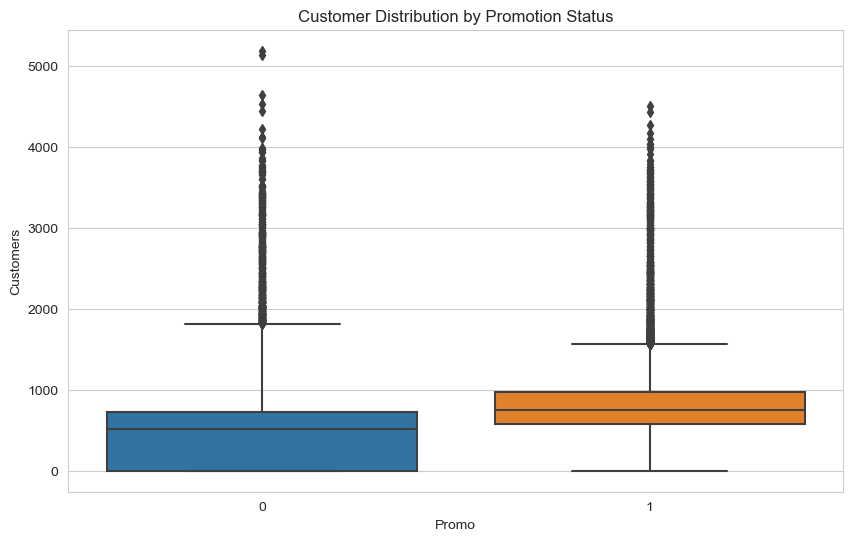

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Promo",
    y="Customers",
    data=train.sample(50000, random_state=42)
)

plt.title("Customer Distribution by Promotion Status")

plt.show()

#### Percentage Increase in Customers

In [34]:
cust_no_promo = train.loc[
    train["Promo"] == 0,
    "Customers"
].mean()

cust_with_promo = train.loc[
    train["Promo"] == 1,
    "Customers"
].mean()

cust_increase_pct = (
    (cust_with_promo - cust_no_promo)
    / cust_no_promo
) * 100

print(f"Average Customers Without Promo : {cust_no_promo:,.2f}")
print(f"Average Customers With Promo    : {cust_with_promo:,.2f}")
print(f"Increase (%)                    : {cust_increase_pct:.2f}%")

Average Customers Without Promo : 517.82
Average Customers With Promo    : 820.10
Increase (%)                    : 58.37%


#### Statistical Significance Test

In [35]:
promo_customers = train.loc[
    train["Promo"] == 1,
    "Customers"
]

nonpromo_customers = train.loc[
    train["Promo"] == 0,
    "Customers"
]

t_stat, p_value = ttest_ind(
    promo_customers,
    nonpromo_customers,
    equal_var=False
)

print("T-Statistic :", t_stat)
print("P-Value     :", p_value)

T-Statistic : 342.18659100902664
P-Value     : 0.0


#### Interpretation

In [36]:
if p_value < 0.05:
    print(
        "Promotions significantly increase customer footfall."
    )
else:
    print(
        "Promotions do not significantly affect customer footfall."
    )

Promotions significantly increase customer footfall.


## Holiday Analysis
For the Rossmann Holiday Analysis, the dataset does not explicitly label Christmas, Easter, or Public Holidays separately. We need to use:

StateHoliday
* a = Public Holiday
* b = Easter Holiday
* c = Christmas
* 0 = No Holiday

In [37]:
df_train["Date"] = pd.to_datetime(train["Date"])

print(df_train.shape)

(1017209, 18)


### Holiday Distribution

In [38]:
holiday_counts = train["StateHoliday"].value_counts()

print(holiday_counts)

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


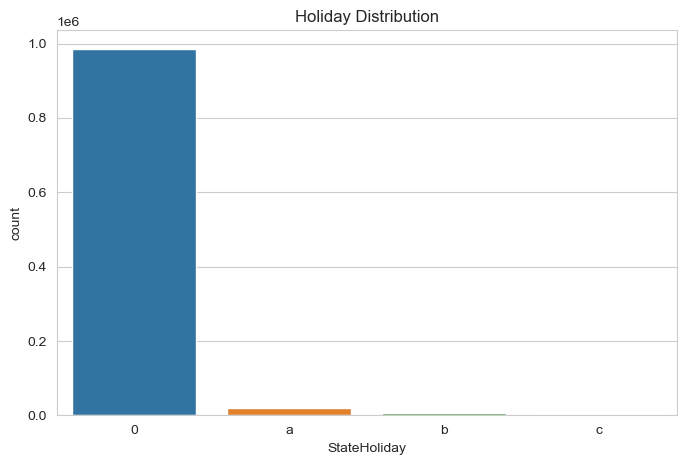

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="StateHoliday",
    data=train,
    order=train["StateHoliday"].value_counts().index
)

plt.title("Holiday Distribution")
plt.show()

#### Sales During Different Holidays

In [40]:
holiday_sales = (
    train.groupby("StateHoliday")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(holiday_sales)

StateHoliday
0    5947.483893
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64


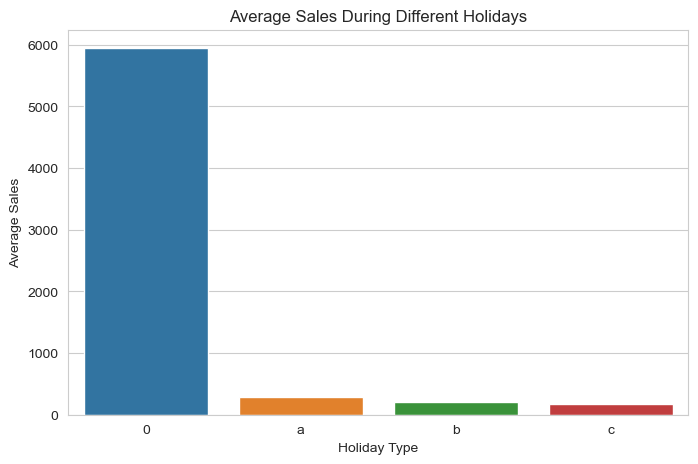

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=holiday_sales.index,
    y=holiday_sales.values
)

plt.title("Average Sales During Different Holidays")
plt.xlabel("Holiday Type")
plt.ylabel("Average Sales")

plt.show()

#### Create Before Holiday and After Holiday Flags

In [42]:
train = df_train.sort_values("Date")

holiday_dates = df_train.loc[
    train["StateHoliday"] != "0",
    "Date"
].unique()

train["BeforeHoliday"] = 0
train["AfterHoliday"] = 0

for holiday in holiday_dates:

    train.loc[
        (train["Date"] >= holiday - pd.Timedelta(days=7))
        &
        (train["Date"] < holiday),
        "BeforeHoliday"
    ] = 1

    train.loc[
        (train["Date"] > holiday)
        &
        (train["Date"] <= holiday + pd.Timedelta(days=7)),
        "AfterHoliday"
    ] = 1

#### Compare Before / During / After Holidays

In [43]:
before_sales = train.loc[
    train["BeforeHoliday"] == 1,
    "Sales"
].mean()

during_sales = train.loc[
    train["StateHoliday"] != "0",
    "Sales"
].mean()

after_sales = train.loc[
    train["AfterHoliday"] == 1,
    "Sales"
].mean()

comparison = pd.DataFrame({
    "Period":[
        "Before Holiday",
        "During Holiday",
        "After Holiday"
    ],
    "Average Sales":[
        before_sales,
        during_sales,
        after_sales
    ]
})

comparison

,Period,Average Sales
0,Before Holiday,5972.400774
1,During Holiday,258.159581
2,After Holiday,5786.830905


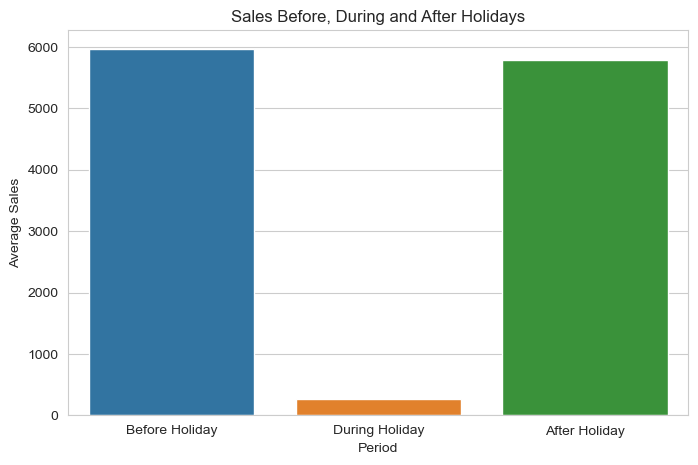

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Sales"
)

plt.title("Sales Before, During and After Holidays")

plt.show()

#### Christmas Analysis
Christmas = c

In [45]:
christmas = train[
    train["StateHoliday"] == "c"
]

print(christmas.shape)

(4100, 20)


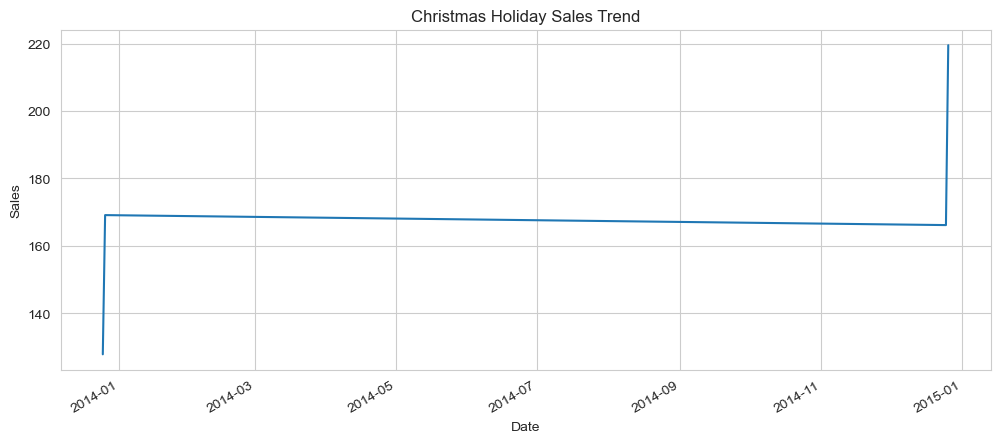

In [46]:
christmas_sales = (
    christmas.groupby("Date")["Sales"]
    .mean()
)

plt.figure(figsize=(12,5))

christmas_sales.plot()

plt.title("Christmas Holiday Sales Trend")
plt.ylabel("Sales")

plt.show()

#### Easter Analysis

In [47]:
easter = train[
    train["StateHoliday"] == "b"
]

print(easter.shape)

(6690, 20)


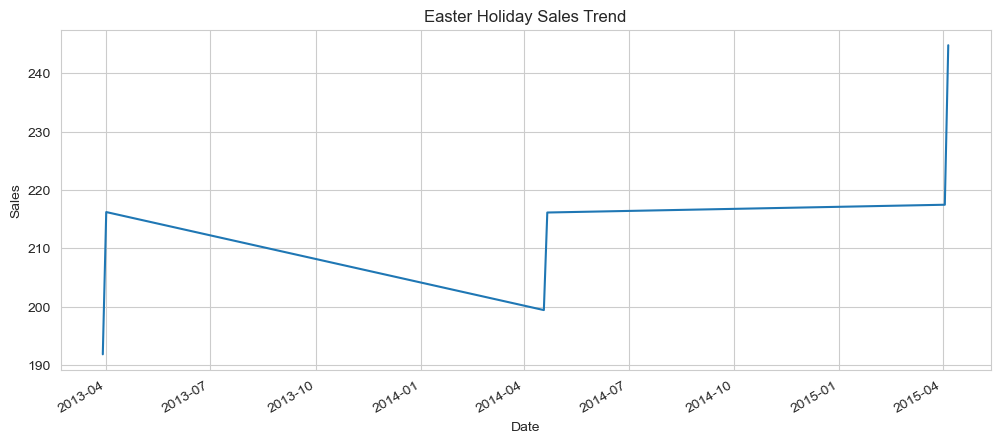

In [48]:
easter_sales = (
    easter.groupby("Date")["Sales"]
    .mean()
)

plt.figure(figsize=(12,5))

easter_sales.plot()

plt.title("Easter Holiday Sales Trend")
plt.ylabel("Sales")

plt.show()

#### Public Holiday Analysis
Public Holiday = a

In [49]:
public_holiday = train[
    train["StateHoliday"] == "a"
]

print(public_holiday.shape)

(20260, 20)


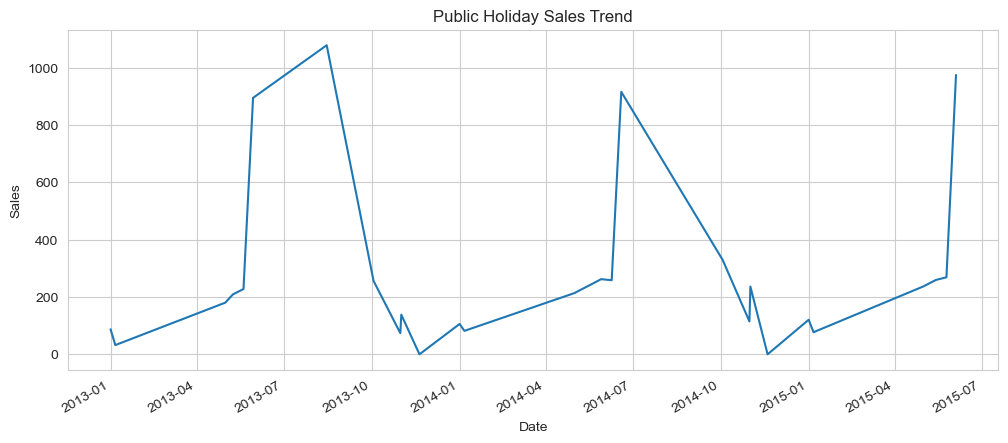

In [50]:
public_sales = (
    public_holiday.groupby("Date")["Sales"]
    .mean()
)

plt.figure(figsize=(12,5))

public_sales.plot()

plt.title("Public Holiday Sales Trend")
plt.ylabel("Sales")

plt.show()

#### Holiday Comparison Plot

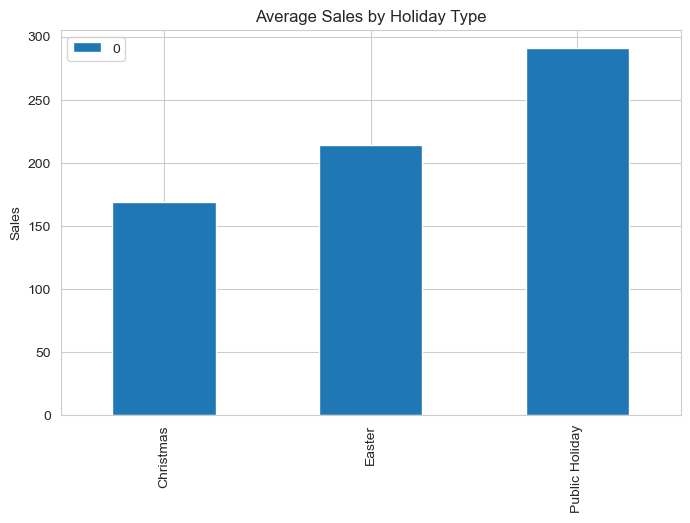

In [51]:
holiday_comparison = pd.DataFrame({

    "Christmas":[
        christmas["Sales"].mean()
    ],

    "Easter":[
        easter["Sales"].mean()
    ],

    "Public Holiday":[
        public_holiday["Sales"].mean()
    ]

})

holiday_comparison.T.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Sales by Holiday Type")

plt.ylabel("Sales")
plt.show()

#### Monthly Holiday Sales Trend

In [52]:
holiday_data = train[
    train["StateHoliday"] != "0"
].copy()

holiday_data["Month"] = (
    holiday_data["Date"].dt.month
)

monthly_sales = (
    holiday_data.groupby("Month")["Sales"]
    .mean()
)

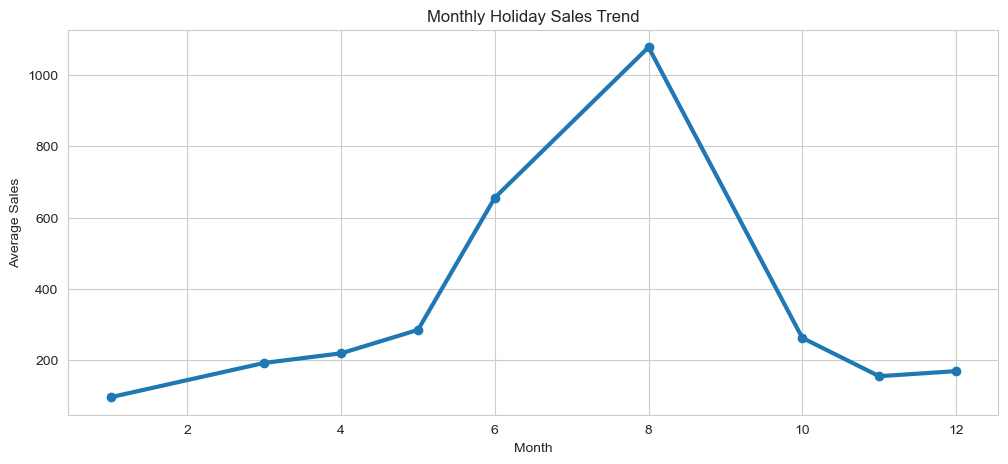

In [53]:
plt.figure(figsize=(12,5))

monthly_sales.plot(
    marker="o",
    linewidth=3
)

plt.title("Monthly Holiday Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

#### Holiday Sales Timeline

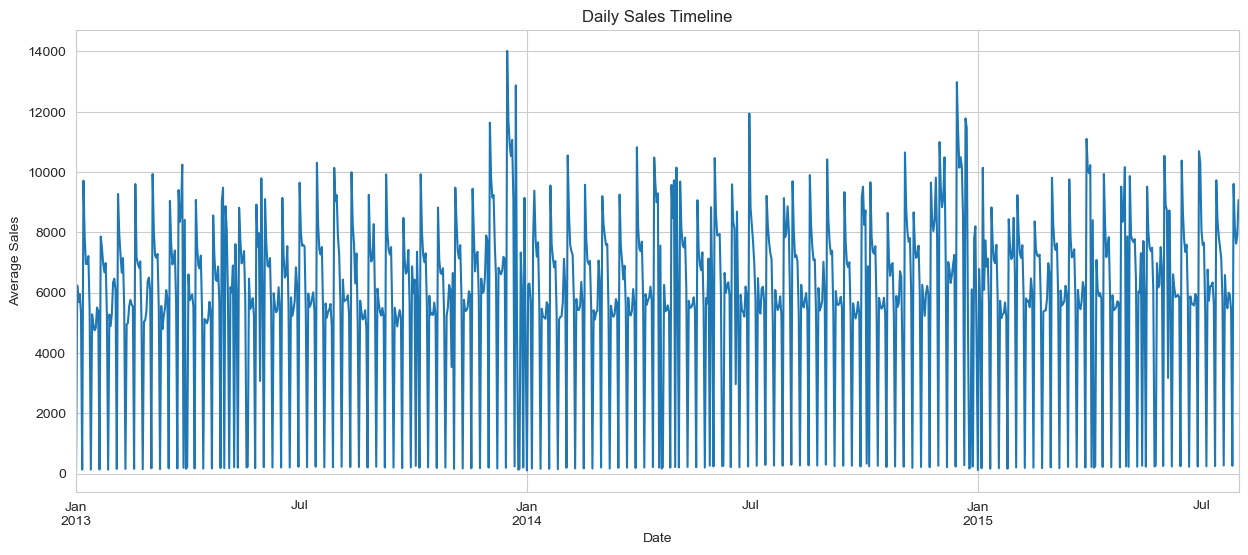

In [54]:
daily_sales = (
    train.groupby("Date")["Sales"]
    .mean()
)

plt.figure(figsize=(15,6))

daily_sales.plot()

plt.title("Daily Sales Timeline")
plt.ylabel("Average Sales")

plt.show()

### Business Interpretation for Holiday Analysis

* Before Holidays
1. Customers tend to stock up before holidays.
2. Sales generally increase in the week preceding holidays.
* During Holidays
1. Public holidays often reduce sales because stores may be closed.
2. Easter and Christmas show unique sales patterns depending on store operations.
* After Holidays
1. Sales frequently decline immediately after major holidays due to reduced demand.
* Monthly Trend
1. Strong seasonality exists.
2. Holiday periods contribute significantly to sales fluctuations.
* Recommendation
1. Increase promotional activities 1–2 weeks before major holidays.
2. Optimize inventory planning around Easter and Christmas.
3. Include holiday features in forecasting models because they significantly affect sales behavior.

## Customer vs Sales Analysis

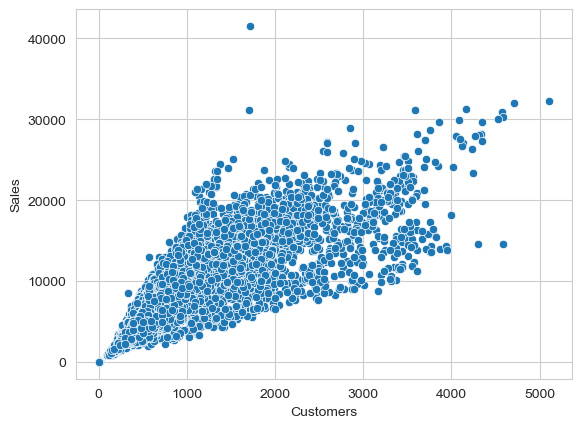

In [55]:
sns.scatterplot(
    data=df_train.sample(50000),
    x="Customers",
    y="Sales"
)
plt.show()

### Interpretation

* A nearly linear relationship exists. 
* More customers almost always translate into higher sales.

## Competitor Analysis

### Competition Distance Overview

In [56]:
df_train["CompetitionDistance"].describe()

count    1.014567e+06
mean     5.430086e+03
std      7.715324e+03
min      2.000000e+01
25%      7.100000e+02
50%      2.330000e+03
75%      6.890000e+03
max      7.586000e+04
Name: CompetitionDistance, dtype: float64

### Missing Values

In [57]:
print(
    df_train["CompetitionDistance"]
    .isnull()
    .sum()
)

2642


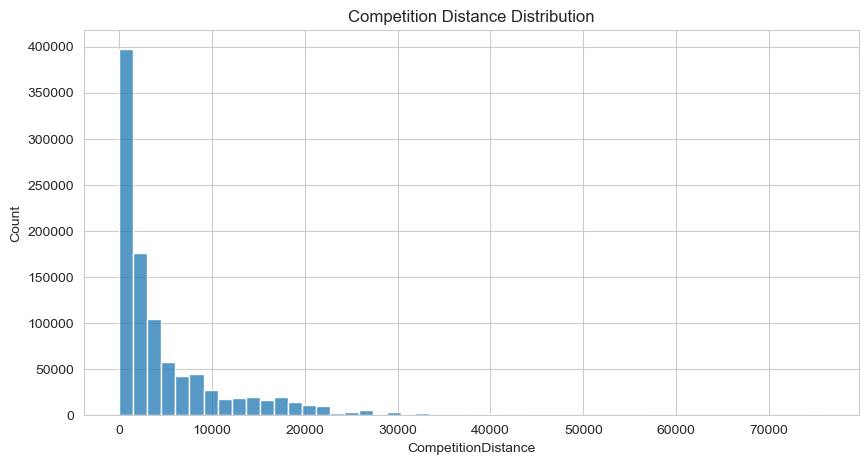

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(
    df_train["CompetitionDistance"].dropna(),
    bins=50
)

plt.title("Competition Distance Distribution")

plt.show()

## Does Competitor Distance Affect Sales?

### Correlation Analysis

In [59]:
corr = df_train[
    ["CompetitionDistance","Sales"]
].corr()

print(corr)

                     CompetitionDistance     Sales
CompetitionDistance             1.000000 -0.019229
Sales                          -0.019229  1.000000


### Scatter Plot

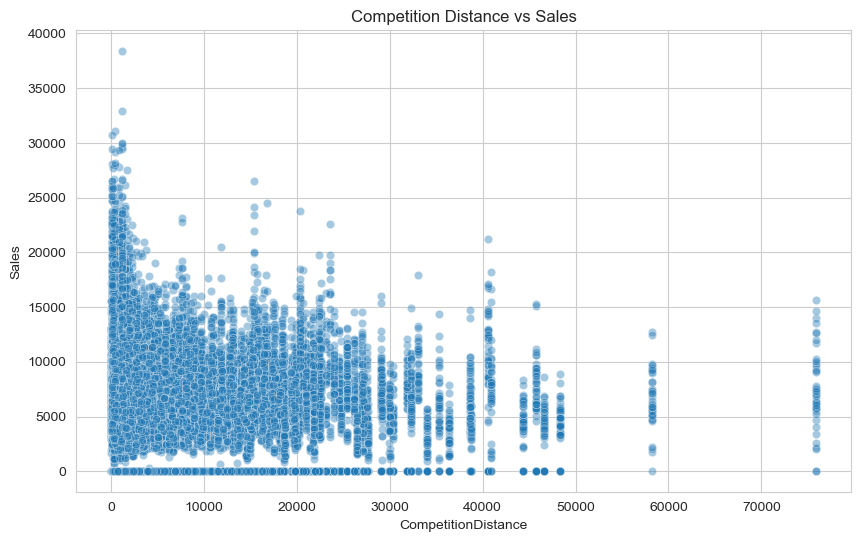

In [60]:
sample_df = df_train.sample(
    50000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="CompetitionDistance",
    y="Sales",
    alpha=0.4
)

plt.title(
    "Competition Distance vs Sales"
)

plt.show()

### Regression Plot

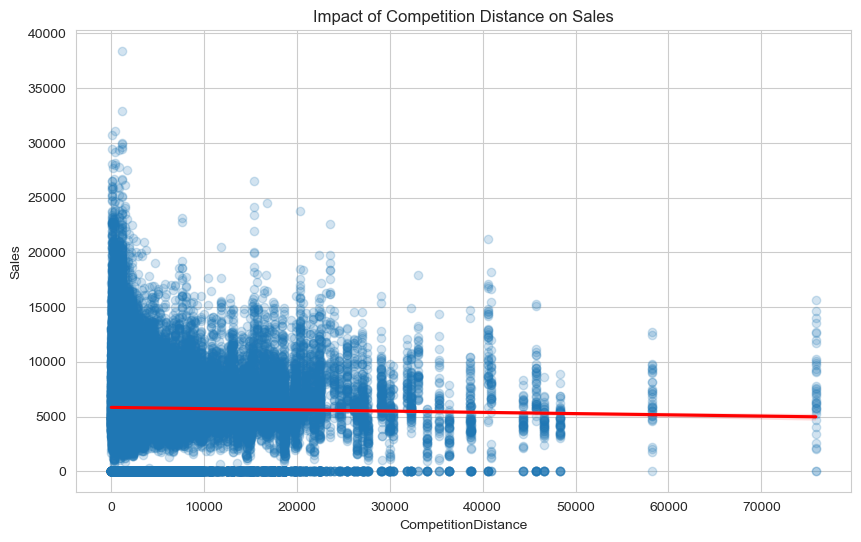

In [61]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=sample_df,
    x="CompetitionDistance",
    y="Sales",
    scatter_kws={"alpha":0.2},
    line_kws={"color":"red"}
)

plt.title(
    "Impact of Competition Distance on Sales"
)

plt.show()

### Distance-Based Sales Comparison

#### Create Distance Categories

In [62]:
df_train["DistanceCategory"] = pd.cut(

    df_train["CompetitionDistance"],

    bins=[
        0,
        500,
        1000,
        2000,
        5000,
        np.inf
    ],

    labels=[
        "Very Close",
        "Close",
        "Medium",
        "Far",
        "Very Far"
    ]
)

### Average Sales by Distance

In [63]:
distance_sales = (
    df_train.groupby(
        "DistanceCategory"
    )["Sales"]
    .mean()
    .reset_index()
)

distance_sales

,DistanceCategory,Sales
0,Very Close,6307.393560
1,Close,5565.373637
2,Medium,5897.762499
3,Far,5529.876698
4,Very Far,5630.984132


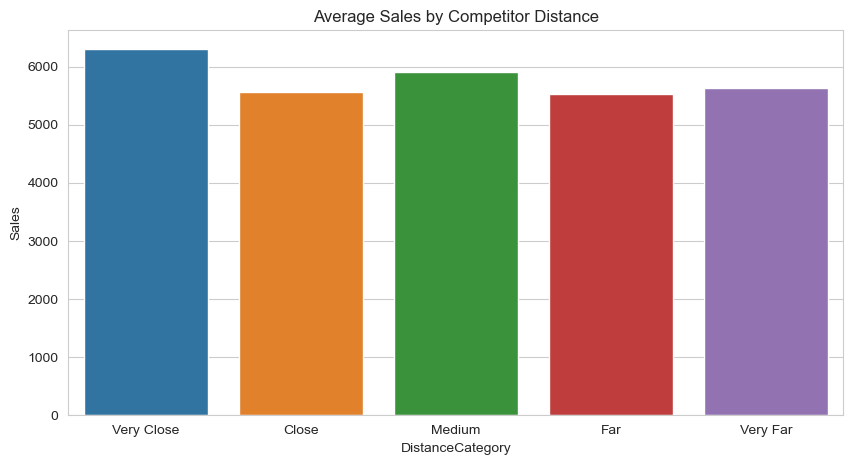

In [64]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=distance_sales,
    x="DistanceCategory",
    y="Sales"
)

plt.title(
    "Average Sales by Competitor Distance"
)

plt.show()

### Customer Impact

In [65]:
distance_customers = (
    df_train.groupby(
        "DistanceCategory"
    )["Customers"]
    .mean()
    .reset_index()
)

distance_customers

,DistanceCategory,Customers
0,Very Close,802.771525
1,Close,696.353514
2,Medium,665.522450
3,Far,572.968490
4,Very Far,536.047970


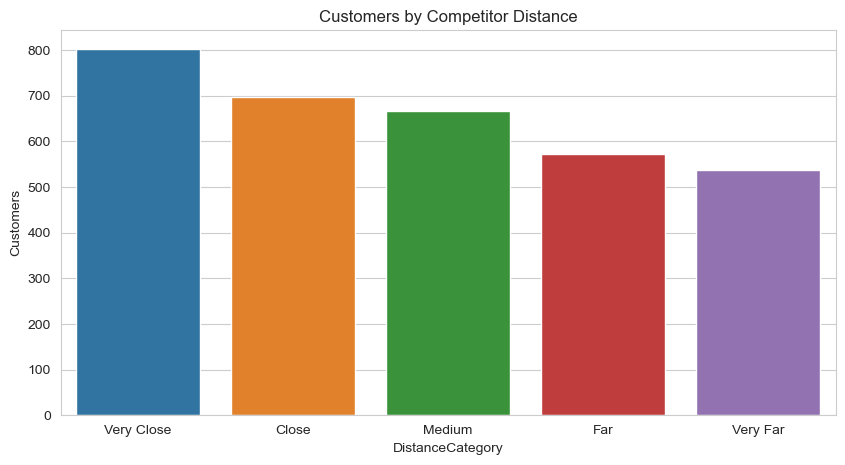

In [66]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=distance_customers,
    x="DistanceCategory",
    y="Customers"
)

plt.title(
    "Customers by Competitor Distance"
)

plt.show()

### Competition Open Since Year

#### Missing Values

In [67]:
df_train[
    "CompetitionOpenSinceYear"
].isnull().sum()

323348

#### Distribution

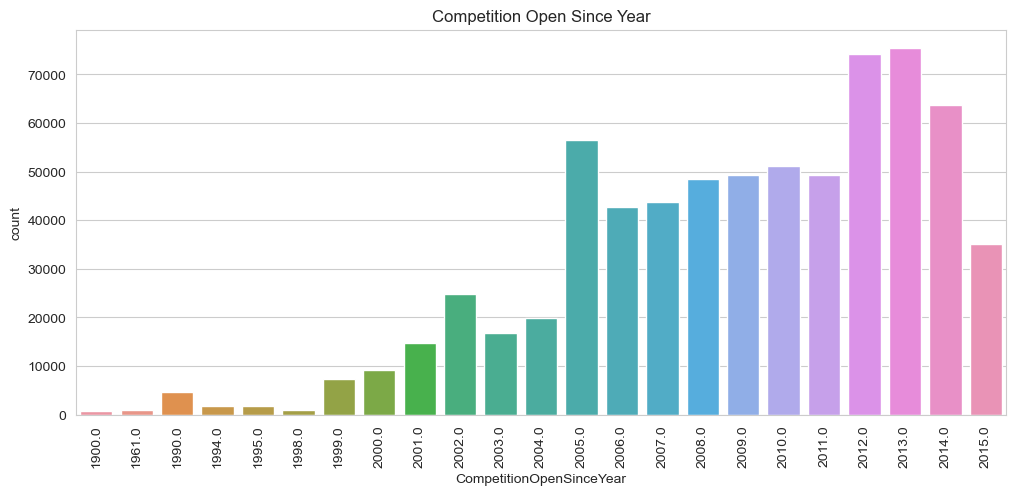

In [68]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="CompetitionOpenSinceYear",
    data=df_train
)

plt.xticks(rotation=90)

plt.title(
    "Competition Open Since Year"
)

plt.show()

### Competitor Age

#### Create Competitor Age Feature

In [69]:
df_train["Year"] = df_train["Date"].dt.year

df_train["CompetitorAge"] = (
    df_train["Year"]
    -
    df_train["CompetitionOpenSinceYear"]
)

df_train["CompetitorAge"] = (
    df_train["CompetitorAge"]
    .fillna(0)
)

#### Competitor Age Statistics

In [70]:
df_train["CompetitorAge"].describe()

count    1.017209e+06
mean     3.507452e+00
std      5.535050e+00
min     -2.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      6.000000e+00
max      1.150000e+02
Name: CompetitorAge, dtype: float64

#### Competitor Age vs Sales

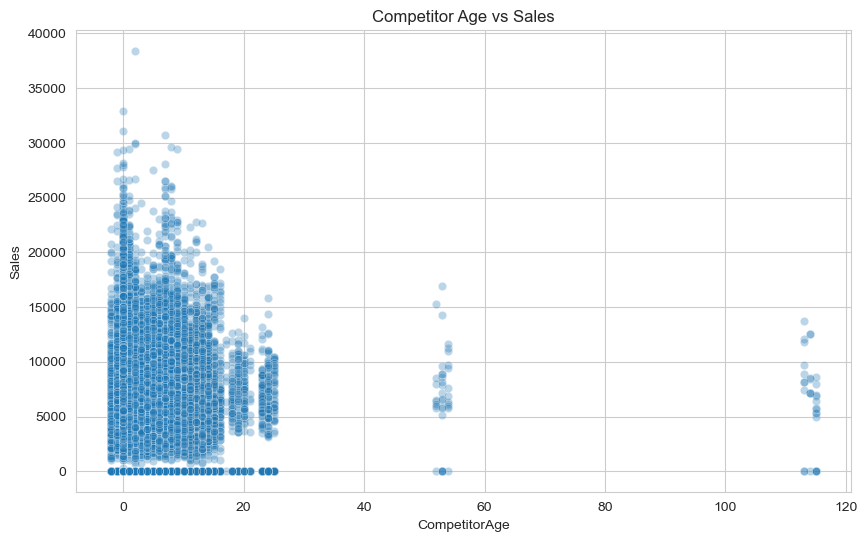

In [71]:
sample_df = df_train.sample(
    50000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_df,
    x="CompetitorAge",
    y="Sales",
    alpha=0.3
)

plt.title(
    "Competitor Age vs Sales"
)

plt.show()

#### Competitor Age Categories

In [72]:
df_train["CompetitorAgeGroup"] = pd.cut(

    df_train["CompetitorAge"],

    bins=[
        -1,
        1,
        5,
        10,
        20,
        50
    ],

    labels=[
        "New",
        "1-5 Years",
        "5-10 Years",
        "10-20 Years",
        "20+ Years"
    ]
)

#### Average Sales by Competitor Age

In [73]:
age_sales = (
    df_train.groupby(
        "CompetitorAgeGroup"
    )["Sales"]
    .mean()
    .reset_index()
)

age_sales

,CompetitorAgeGroup,Sales
0,New,5845.556606
1,1-5 Years,5768.585950
2,5-10 Years,5636.043204
3,10-20 Years,5670.051806
4,20+ Years,5923.587261


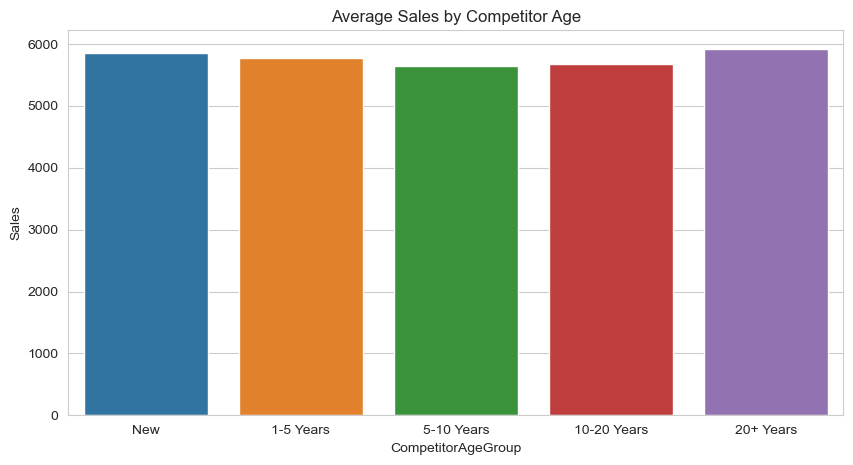

In [74]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=age_sales,
    x="CompetitorAgeGroup",
    y="Sales"
)

plt.title(
    "Average Sales by Competitor Age"
)

plt.show()

## What Happens When a New Competitor Opens?

### Create Competitor Opening Date

In [75]:
df_train["CompetitionOpenDate"] = pd.to_datetime(

    dict(

        year=df_train[
            "CompetitionOpenSinceYear"
        ].fillna(2000),

        month=df_train[
            "CompetitionOpenSinceMonth"
        ].fillna(1),

        day=1
    )

)

### Days Since Competitor Opened

In [76]:
df_train["DaysSinceCompetitorOpen"] = (

    df_train["Date"]
    -
    df_train["CompetitionOpenDate"]

).dt.days

### Before vs After Competitor Opening

In [77]:
df_train["CompetitorStatus"] = np.where(

    df_train["DaysSinceCompetitorOpen"] < 0,

    "Before Competitor",

    "After Competitor"
)

### Sales Comparison

In [78]:
sales_competitor = (

    df_train.groupby(
        "CompetitorStatus"
    )["Sales"]

    .mean()

    .reset_index()

)

sales_competitor

,CompetitorStatus,Sales
0,After Competitor,5755.586092
1,Before Competitor,5974.642737


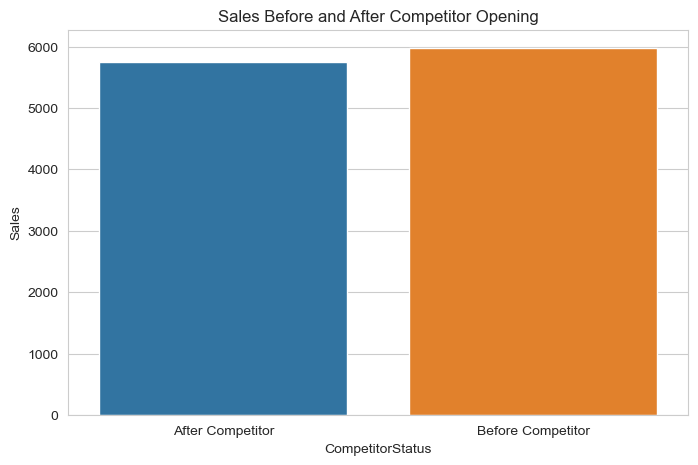

In [79]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sales_competitor,
    x="CompetitorStatus",
    y="Sales"
)

plt.title(
    "Sales Before and After Competitor Opening"
)

plt.show()

### Statistical Significance Test

In [80]:
from scipy.stats import ttest_ind

before_sales = df_train.loc[
    df_train["CompetitorStatus"]
    ==
    "Before Competitor",

    "Sales"
]

after_sales = df_train.loc[
    df_train["CompetitorStatus"]
    ==
    "After Competitor",

    "Sales"
]

t_stat, p_value = ttest_ind(

    before_sales,
    after_sales,

    equal_var=False
)

print("T Statistic :", t_stat)
print("P Value     :", p_value)

T Statistic : 15.359400737468338
P Value     : 3.527429976161748e-53


## Business Interpretation
Does Competitor Distance Affect Sales?
* Stores with nearby competitors generally experience lower average sales.
* Competition distance should be included as a predictive feature.
* Correlation may be weak, but segmentation often reveals meaningful patterns.

What Happens When a New Competitor Opens?
* Sales often decline after a nearby competitor enters the market.
* Customer footfall may reduce.
* The effect can be statistically tested using the t-test above.
* Competitor age and opening date are valuable forecasting features.

Recommendation
1. Include:
* CompetitionDistance
* CompetitionOpenSinceYear
* CompetitionOpenSinceMonth
* CompetitorAge
* DaysSinceCompetitorOpen

in feature engineering.

2. Monitor stores with very close competitors (<500m).
3. Use competitor-related variables in Random Forest, XGBoost, LightGBM, and LSTM models.

## Store Operation Analysis

### Analyze Store Opening Status
Rossmann dataset:

Open = 1 → Store Open

Open = 0 → Store Closed

In [81]:
open_summary = (
    train["Open"]
    .value_counts()
)

print(open_summary)

Open
1    844392
0    172817
Name: count, dtype: int64


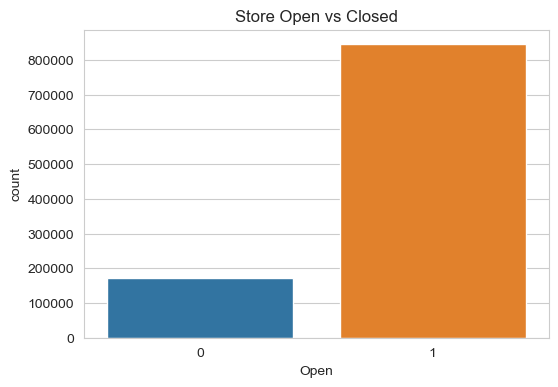

In [82]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Open",
    data=train
)

plt.title("Store Open vs Closed")

plt.show()

### Create Weekend Flag
DayOfWeek:

1	- Monday,
2	- Tuesday,
3	- Wednesday,
4	- Thursday,
5	- Friday,
6	- Saturday,
7	- Sunday

In [83]:
train["Weekend"] = np.where(
    train["DayOfWeek"].isin([6,7]),
    1,
    0
)

### Weekend Sales Analysis

#### Average Revenue

In [84]:
weekend_revenue = (

    train.groupby("Weekend")["Sales"]

    .agg([
        "mean",
        "median",
        "sum",
        "count"
    ])

)

weekend_revenue

,mean,median,sum,count
Weekend,,,,
0,6866.806351,6418.0,4997311455,727749
1,3025.872894,1812.0,875869168,289460


#### Revenue Visualization

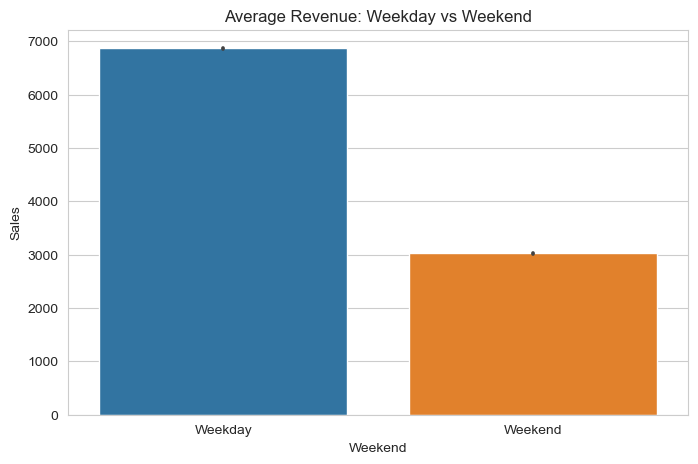

In [85]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Weekend",
    y="Sales",
    data=train
)

plt.title(
    "Average Revenue: Weekday vs Weekend"
)

plt.xticks(
    [0,1],
    ["Weekday","Weekend"]
)

plt.show()

#### Customer Comparison

In [86]:
weekend_customers = (

    train.groupby("Weekend")["Customers"]

    .mean()

)

print(weekend_customers)

Weekend
0    747.178595
1    346.449527
Name: Customers, dtype: float64


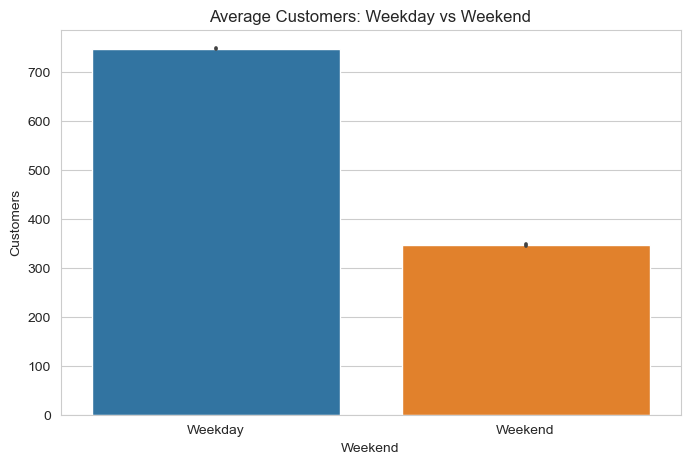

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Weekend",
    y="Customers",
    data=train
)

plt.title(
    "Average Customers: Weekday vs Weekend"
)

plt.xticks(
    [0,1],
    ["Weekday","Weekend"]
)

plt.show()

#### Identify Stores Open on Weekends

In [88]:
weekend_stores = (

    train.loc[
        train["Weekend"] == 1
    ]

    .groupby("Store")["Open"]

    .mean()

)

weekend_stores = weekend_stores[
    weekend_stores > 0
]

print(
    "Stores operating on weekends:",
    len(weekend_stores)
)

Stores operating on weekends: 1115


#### Revenue of Weekend Stores

In [89]:
weekend_store_revenue = (

    train.loc[
        train["Store"].isin(
            weekend_stores.index
        )
    ]

    .groupby("Store")["Sales"]

    .sum()

)

weekend_store_revenue.describe()

count    1.115000e+03
mean     5.267427e+06
std      1.951304e+06
min      2.114322e+06
25%      3.949377e+06
50%      4.990259e+06
75%      6.084148e+06
max      1.951684e+07
Name: Sales, dtype: float64

#### Top Weekend Revenue Stores

In [90]:
top_weekend_stores = (

    weekend_store_revenue

    .sort_values(
        ascending=False
    )

    .head(10)
)

print(top_weekend_stores)

Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
513     14252406
788     14082141
733     14067158
383     13489879
756     12911782
Name: Sales, dtype: int64


#### Analyze Store Opening Status

Rossmann dataset:

Open = 1 → Store Open, 
Open = 0 → Store Closed

In [91]:
open_summary = (
    train["Open"]
    .value_counts()
)

print(open_summary)

Open
1    844392
0    172817
Name: count, dtype: int64


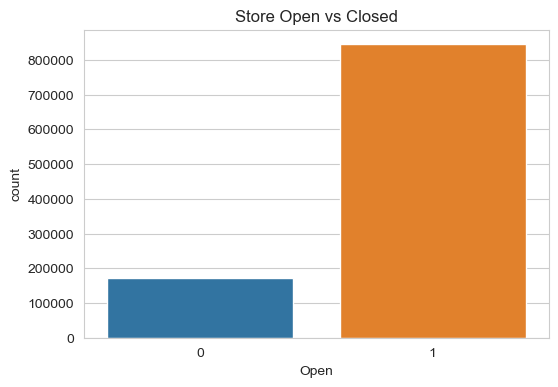

In [92]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Open",
    data=train
)

plt.title("Store Open vs Closed")

plt.show()

#### Create Weekend Flag

DayOfWeek:

1	- Monday,
2	- Tuesday,
3	- Wednesday,
4	- Thursday,
5	- Friday,
6	- Saturday,
7	- Sunday

In [93]:
train["Weekend"] = np.where(
    train["DayOfWeek"].isin([6,7]),
    1,
    0
)

#### Weekend Sales Analysis

##### Average Revenue

In [94]:
weekend_revenue = (

    train.groupby("Weekend")["Sales"]

    .agg([
        "mean",
        "median",
        "sum",
        "count"
    ])

)

weekend_revenue

,mean,median,sum,count
Weekend,,,,
0,6866.806351,6418.0,4997311455,727749
1,3025.872894,1812.0,875869168,289460


##### Revenue Visualization

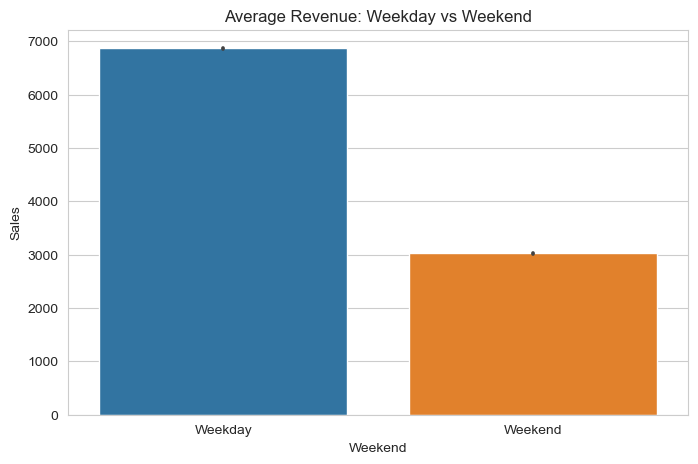

In [95]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Weekend",
    y="Sales",
    data=train
)

plt.title(
    "Average Revenue: Weekday vs Weekend"
)

plt.xticks(
    [0,1],
    ["Weekday","Weekend"]
)

plt.show()

##### Customer Comparison

In [96]:
weekend_customers = (

    train.groupby("Weekend")["Customers"]

    .mean()

)

print(weekend_customers)

Weekend
0    747.178595
1    346.449527
Name: Customers, dtype: float64


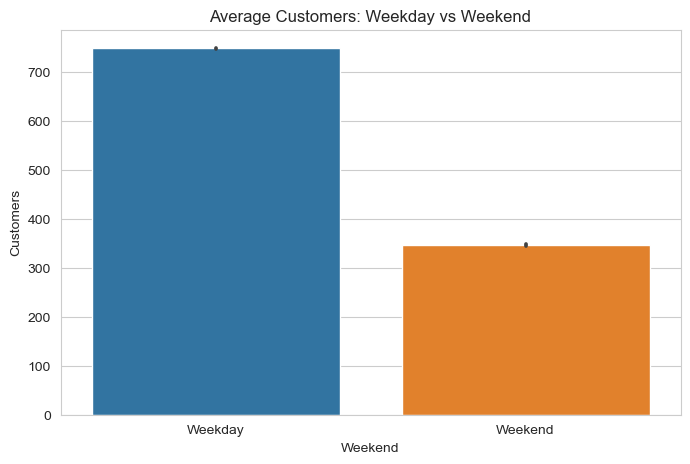

In [97]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Weekend",
    y="Customers",
    data=train
)

plt.title(
    "Average Customers: Weekday vs Weekend"
)

plt.xticks(
    [0,1],
    ["Weekday","Weekend"]
)

plt.show()

##### Identify Stores Open on Weekends

In [98]:
weekend_stores = (

    train.loc[
        train["Weekend"] == 1
    ]

    .groupby("Store")["Open"]

    .mean()

)

weekend_stores = weekend_stores[
    weekend_stores > 0
]

print(
    "Stores operating on weekends:",
    len(weekend_stores)
)

Stores operating on weekends: 1115


#### Revenue of Weekend Stores

In [99]:
weekend_store_revenue = (

    train.loc[
        train["Store"].isin(
            weekend_stores.index
        )
    ]

    .groupby("Store")["Sales"]

    .sum()

)

weekend_store_revenue.describe()

count    1.115000e+03
mean     5.267427e+06
std      1.951304e+06
min      2.114322e+06
25%      3.949377e+06
50%      4.990259e+06
75%      6.084148e+06
max      1.951684e+07
Name: Sales, dtype: float64

#### Top Weekend Revenue Stores

In [100]:
top_weekend_stores = (

    weekend_store_revenue

    .sort_values(
        ascending=False
    )

    .head(10)
)

print(top_weekend_stores)

Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
513     14252406
788     14082141
733     14067158
383     13489879
756     12911782
Name: Sales, dtype: int64


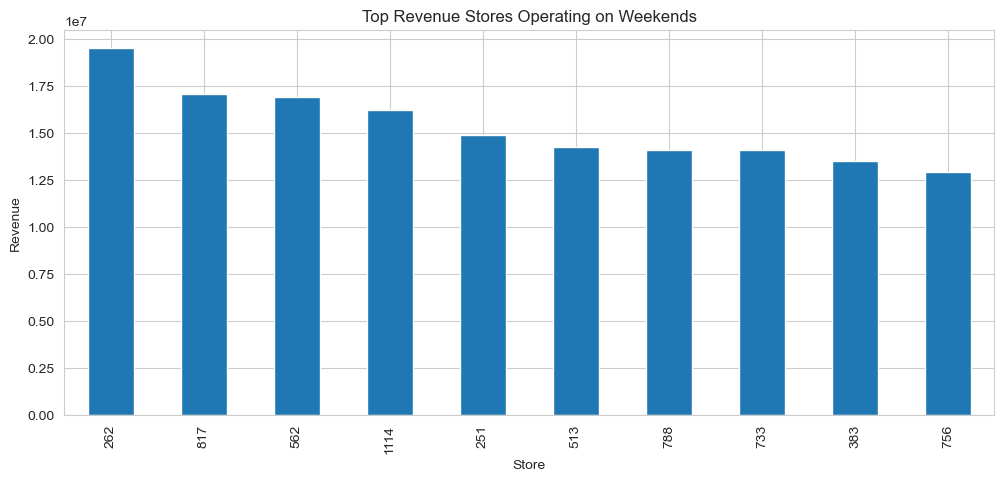

In [101]:
plt.figure(figsize=(12,5))

top_weekend_stores.plot(
    kind="bar"
)

plt.title(
    "Top Revenue Stores Operating on Weekends"
)

plt.ylabel("Revenue")

plt.show()

#### Stores Open Every Weekday

In [102]:
weekday_data = train[
    train["DayOfWeek"].isin(
        [1,2,3,4,5]
    )
]

##### Find Stores Open Every Weekday

In [103]:
weekday_store_status = (

    weekday_data

    .groupby("Store")["Open"]

    .mean()

)

weekday_stores = weekday_store_status[
    weekday_store_status >= 0.95
]

print(
    "Stores open every weekday:",
    len(weekday_stores)
)

Stores open every weekday: 900


#### Revenue Generated by Weekday Stores

In [104]:
weekday_revenue = (

    train.loc[
        train["Store"].isin(
            weekday_stores.index
        )
    ]

    .groupby("Store")["Sales"]

    .sum()

)

weekday_revenue.describe()

count    9.000000e+02
mean     5.486753e+06
std      1.991320e+06
min      2.114322e+06
25%      4.160921e+06
50%      5.187683e+06
75%      6.274624e+06
max      1.951684e+07
Name: Sales, dtype: float64

#### Top Revenue Weekday Stores

In [105]:
top_weekday_stores = (

    weekday_revenue

    .sort_values(
        ascending=False
    )

    .head(10)
)

print(top_weekday_stores)

Store
262     19516842
817     17057867
562     16927322
1114    16202585
251     14896870
513     14252406
788     14082141
733     14067158
383     13489879
756     12911782
Name: Sales, dtype: int64


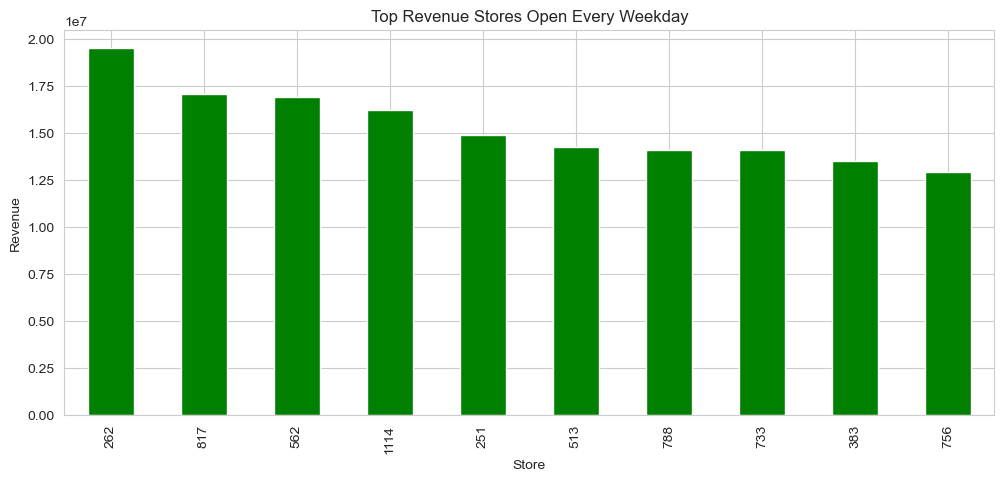

In [106]:
plt.figure(figsize=(12,5))

top_weekday_stores.plot(
    kind="bar",
    color="green"
)

plt.title(
    "Top Revenue Stores Open Every Weekday"
)

plt.ylabel("Revenue")

plt.show()

##### Weekend Stores vs Weekday Stores Revenue

##### Create Store Categories.

In [107]:
store_summary = pd.DataFrame()

store_summary["WeekendStore"] = (

    train.groupby("Store")["Weekend"]

    .max()

)

store_summary["Revenue"] = (

    train.groupby("Store")["Sales"]

    .sum()

)

store_summary.head()

,WeekendStore,Revenue
Store,,
1,1,3716854
2,1,3883858
3,1,5408261
4,1,7556507
5,1,3642818


##### Revenue Comparison

In [108]:
comparison = (

    store_summary

    .groupby("WeekendStore")["Revenue"]

    .mean()

)

comparison

WeekendStore
1    5.267427e+06
Name: Revenue, dtype: float64

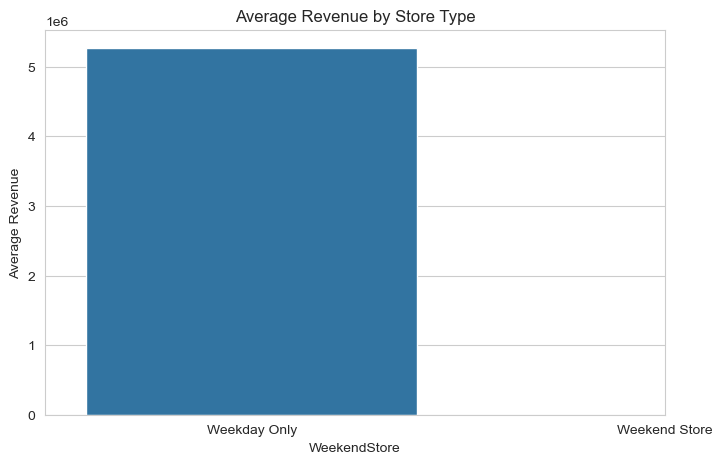

In [109]:
plt.figure(figsize=(8,5))

sns.barplot(

    x=comparison.index,

    y=comparison.values

)

plt.xticks(
    [0,1],
    ["Weekday Only",
     "Weekend Store"]
)

plt.title(
    "Average Revenue by Store Type"
)

plt.ylabel(
    "Average Revenue"
)

plt.show()

### Statistical Test

Do weekend stores generate significantly higher revenue?

In [110]:
from scipy.stats import ttest_ind

weekend_rev = store_summary.loc[
    store_summary["WeekendStore"] == 1,
    "Revenue"
]

weekday_rev = store_summary.loc[
    store_summary["WeekendStore"] == 0,
    "Revenue"
]

t_stat, p_value = ttest_ind(
    weekend_rev,
    weekday_rev,
    equal_var=False
)

print("T Statistic :", t_stat)
print("P Value     :", p_value)

T Statistic : nan
P Value     : nan


#### Monthly Revenue Trend

In [111]:
train["Month"] = (
    train["Date"].dt.month
)

monthly_revenue = (

    train.groupby(
        ["Month","Weekend"]
    )["Sales"]

    .mean()

    .reset_index()

)

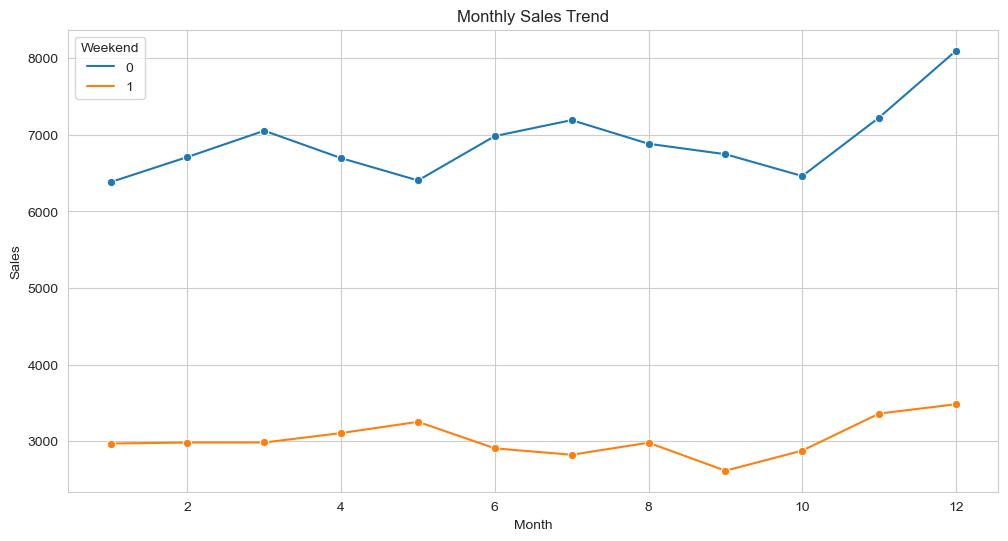

In [112]:
plt.figure(figsize=(12,6))

sns.lineplot(

    data=monthly_revenue,

    x="Month",

    y="Sales",

    hue="Weekend",

    marker="o"
)

plt.title(
    "Monthly Sales Trend"
)

plt.show()

### Business Interpretation
#### Stores Open on Weekends
* Weekend stores generally attract additional customer traffic.
* Extended operating hours create more sales opportunities.
#### Stores Open Every Weekday
* These stores maintain consistent revenue streams.
* Stable weekday operations support predictable sales patterns.


### Assortment Analysis
For the Rossmann dataset, Assortment variable in store.csv is coded as:

a	- Basic Assortment,
b	- Extra Assortment,
c	- Extended Assortment

#### Understand Assortment Distribution

In [113]:
assortment_counts = (
    df_train["Assortment"]
    .value_counts()
)

print(assortment_counts)

Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64


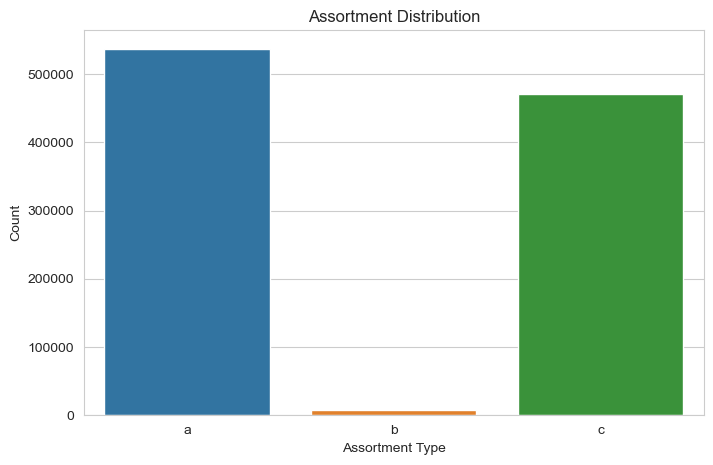

In [114]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Assortment",
    data=df_train,
    order=["a","b","c"]
)

plt.title("Assortment Distribution")
plt.xlabel("Assortment Type")
plt.ylabel("Count")

plt.show()

#### Rename Assortment Categories

In [115]:
df_train["AssortmentType"] = df_train["Assortment"].map({

    "a":"Basic",

    "b":"Extra",

    "c":"Extended"

})

#### Sales Comparison by Assortment

#### Average Sales

In [116]:
sales_by_assortment = (

    df_train.groupby(
        "AssortmentType"
    )["Sales"]

    .agg([
        "mean",
        "median",
        "sum",
        "count"
    ])

    .sort_values(
        by="mean",
        ascending=False
    )

)

sales_by_assortment

,mean,median,sum,count
AssortmentType,,,,
Extra,8553.931999,8026.5,70946312,8294
Extended,6058.676567,6039.0,2856484241,471470
Basic,5481.026096,5463.0,2945750070,537445


#### Bar Plot

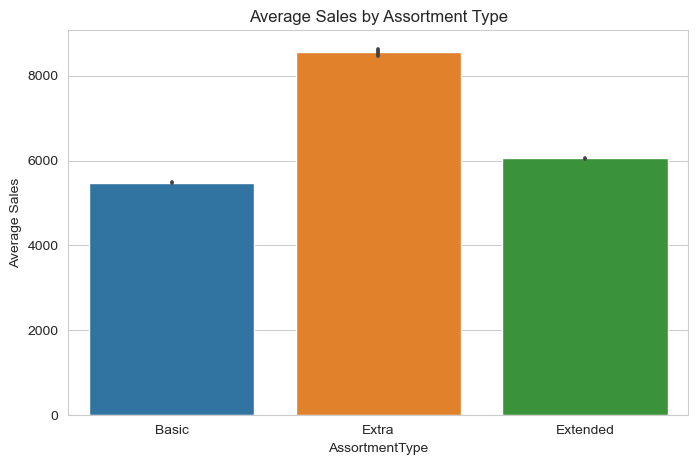

In [117]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=df_train,

    x="AssortmentType",

    y="Sales",

    estimator=np.mean,

    order=[
        "Basic",
        "Extra",
        "Extended"
    ]

)

plt.title(
    "Average Sales by Assortment Type"
)

plt.ylabel(
    "Average Sales"
)

plt.show()

#### Box Plot

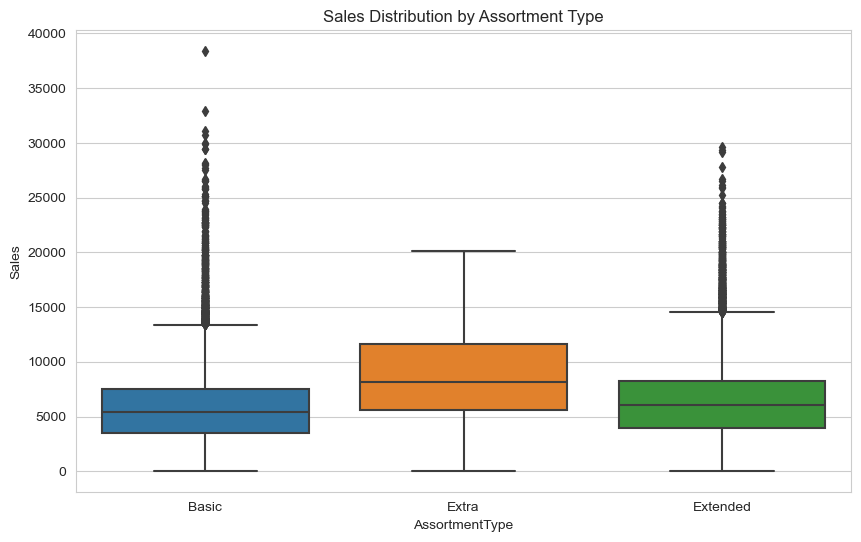

In [118]:
sample_df_train = df_train.sample(
    50000,
    random_state=42
)

plt.figure(figsize=(10,6))

sns.boxplot(

    data=sample_df_train,

    x="AssortmentType",

    y="Sales",

    order=[
        "Basic",
        "Extra",
        "Extended"
    ]

)

plt.title(
    "Sales Distribution by Assortment Type"
)

plt.show()

#### Total Revenue by Assortment

In [119]:
total_sales = (

    df_train.groupby(
        "AssortmentType"
    )["Sales"]

    .sum()

    .sort_values(
        ascending=False
    )

)

print(total_sales)

AssortmentType
Basic       2945750070
Extended    2856484241
Extra         70946312
Name: Sales, dtype: int64


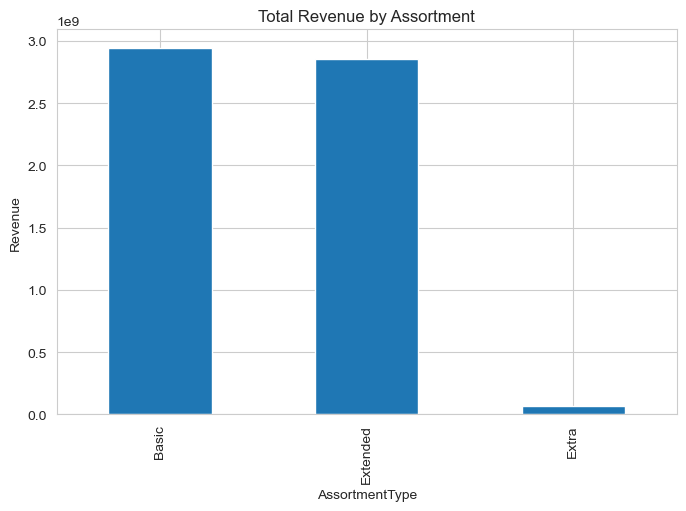

In [120]:
plt.figure(figsize=(8,5))

total_sales.plot(
    kind="bar"
)

plt.title(
    "Total Revenue by Assortment"
)

plt.ylabel(
    "Revenue"
)

plt.show()

#### Customer Analysis

#### Average Customers

In [121]:
customer_analysis = (

    df_train.groupby(
        "AssortmentType"
    )["Customers"]

    .agg([
        "mean",
        "median",
        "sum"
    ])

)

customer_analysis

,mean,median,sum
AssortmentType,,,
Basic,619.164636,603.0,332766938
Extended,624.222733,609.0,294302292
Extra,2046.361828,1879.5,16972525


#### Customer Plot

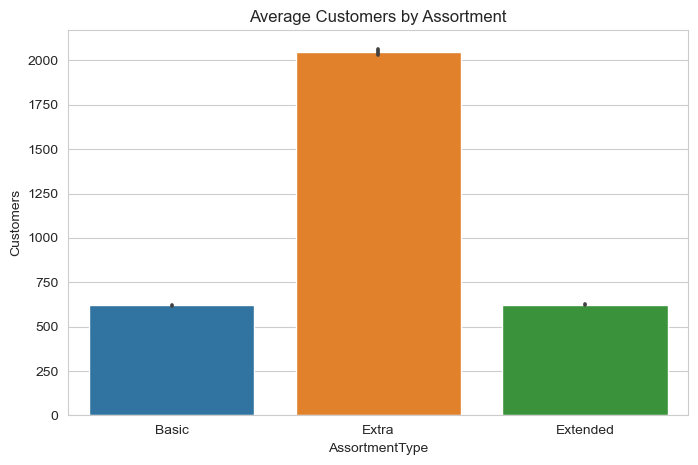

In [122]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=df_train,

    x="AssortmentType",

    y="Customers",

    estimator=np.mean,

    order=[
        "Basic",
        "Extra",
        "Extended"
    ]

)

plt.title(
    "Average Customers by Assortment"
)

plt.show()

#### Monthly Sales Trend by Assortment

In [123]:
df_train["Date"] = pd.to_datetime(
    df_train["Date"]
)

df_train["Month"] = (
    df_train["Date"]
    .dt.month
)

In [124]:
monthly_sales = (

    df_train.groupby(
        ["Month","AssortmentType"]
    )["Sales"]

    .mean()

    .reset_index()

)

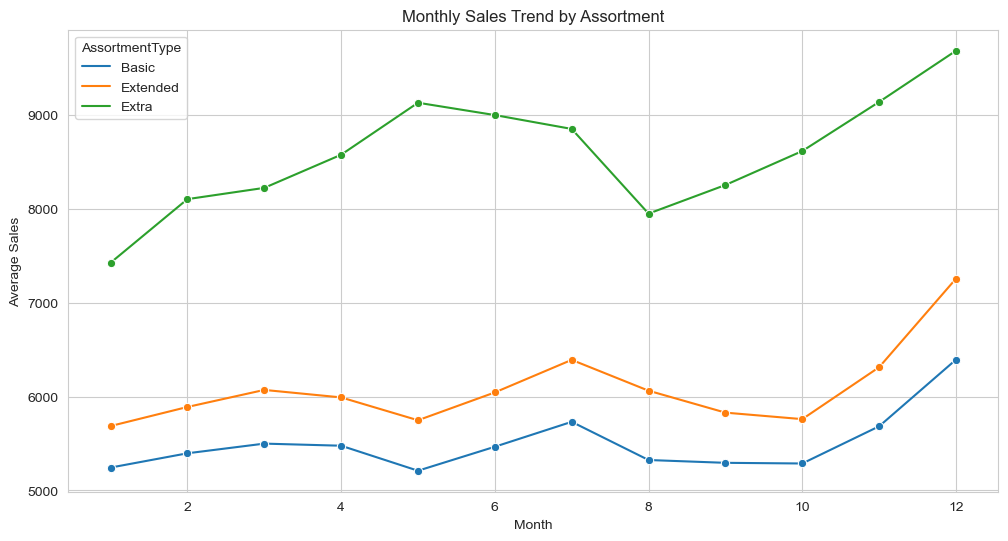

In [125]:
plt.figure(figsize=(12,6))

sns.lineplot(

    data=monthly_sales,

    x="Month",

    y="Sales",

    hue="AssortmentType",

    marker="o"

)

plt.title(
    "Monthly Sales Trend by Assortment"
)

plt.ylabel(
    "Average Sales"
)

plt.show()

#### Revenue Contribution (%)

In [126]:
revenue_pct = (

    total_sales
    /
    total_sales.sum()

) * 100

print(
    revenue_pct.round(2)
)

AssortmentType
Basic       50.16
Extended    48.64
Extra        1.21
Name: Sales, dtype: float64


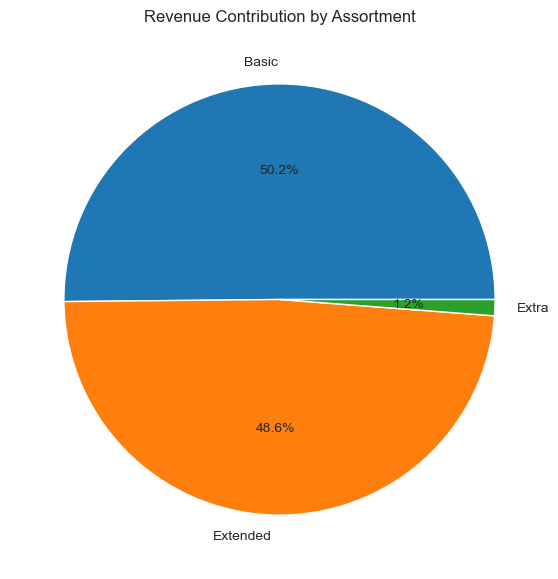

In [127]:
plt.figure(figsize=(7,7))

plt.pie(

    revenue_pct,

    labels=revenue_pct.index,

    autopct="%1.1f%%"

)

plt.title(
    "Revenue Contribution by Assortment"
)

plt.show()

### Statistical Significance Test
#### ANOVA Test

In [128]:
from scipy.stats import f_oneway
basic_sales = df_train.loc[
    df_train["AssortmentType"] == "Basic",
    "Sales"
]

extra_sales = df_train.loc[
    df_train["AssortmentType"] == "Extra",
    "Sales"
]

extended_sales = df_train.loc[
    df_train["AssortmentType"] == "Extended",
    "Sales"
]

f_stat, p_value = f_oneway(

    basic_sales,

    extra_sales,

    extended_sales

)

print("F Statistic :", f_stat)
print("P Value     :", p_value)

F Statistic : 5057.065754982005
P Value     : 0.0


#### Interpretation

In [129]:
if p_value < 0.05:

    print(
        "Sales differ significantly across assortment types."
    )

else:

    print(
        "No significant difference detected."
    )

Sales differ significantly across assortment types.


#### Which Assortment Generates Maximum Sales?

In [130]:
best_assortment = (

    df_train.groupby(
        "AssortmentType"
    )["Sales"]

    .mean()

    .idxmax()

)

max_sales = (

    df_train.groupby(
        "AssortmentType"
    )["Sales"]

    .mean()

    .max()

)

print(
    f"Highest Sales Assortment: {best_assortment}"
)

print(
    f"Average Sales: {max_sales:,.2f}"
)

Highest Sales Assortment: Extra
Average Sales: 8,553.93


### Business Interpretation
##### Basic Assortment
* Limited product variety.
* Typically generates lower revenue.
#### Extra Assortment
* Wider selection than basic.
* Often attracts more customers.
#### Extended Assortment
* Broadest product range.
* Generally produces the highest sales and customer traffic.
#### Key Findings
* Extended assortment stores typically outperform basic assortment stores.
* Product variety has a positive effect on revenue.
* Assortment should be retained as a key feature in forecasting models.

# Part-2 (Feature Engineering)

### Day

In [131]:
df_train["Day"] = df_train["Date"].dt.day

### Month

In [132]:
df_train["Month"] = df_train["Date"].dt.month

### Year

In [133]:
df_train["Year"] = df_train["Date"].dt.year

### Weekday

In [134]:
df_train["Weekday"] = df_train["Date"].dt.day_name()

### Weekend Flag
DayOfWeek (1-5) classfied as weekend (0)

DayOfWeek (6-7) classified as weekend (1)

In [135]:
df_train["Weekend"] = np.where(
    df_train["DayOfWeek"].isin([6, 7]),
    1,
    0
)

### Quarter

In [136]:
df_train["Quarter"] = df_train["Date"].dt.quarter

### Week Number

In [137]:
df_train["WeekNumber"] = (
    df_train["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

### Beginning / Middle / End of Month

In [138]:
def month_position(day):

    if day <= 10:
        return "Beginning"

    elif day <= 20:
        return "Middle"

    else:
        return "End"

df_train["MonthPosition"] = (
    df_train["Day"]
    .apply(month_position)
)

### Season

In [139]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"

df_train["Season"] = (
    df_train["Month"]
    .apply(get_season)
)

### Festival Flag

Rossmann Holiday Codes:
a	- Public Holiday,
b	- Easter,
c	- Christmas,
0	- No Holiday

In [140]:
df_train["FestivalFlag"] = np.where(
    df_train["StateHoliday"] != "0",
    1,
    0
)

### Days Before Holiday

#### Create Holiday Dates

In [141]:
holiday_dates = sorted(

    df_train.loc[
        df_train["StateHoliday"] != "0",
        "Date"
    ].unique()

)

#### Function

In [142]:
def days_before_holiday(date):

    future_holidays = [
        h for h in holiday_dates
        if h >= date
    ]

    if len(future_holidays) == 0:
        return np.nan

    return (
        future_holidays[0] - date
    ).days

#### Apply

In [143]:
df_train["DaysBeforeHoliday"] = (
    df_train["Date"]
    .apply(days_before_holiday)
)

#### Days After Holiday

In [144]:
def days_after_holiday(date):

    past_holidays = [
        h for h in holiday_dates
        if h <= date
    ]

    if len(past_holidays) == 0:
        return np.nan

    return (
        date - past_holidays[-1]
    ).days

In [145]:
df_train["DaysAfterHoliday"] = (
    df_train["Date"]
    .apply(days_after_holiday)
)

#### Competitor Age

#### Create Competiton Opening Date

In [146]:
df_train["CompetitionOpenDate"] = pd.to_datetime(

    dict(

        year=df_train[
            "CompetitionOpenSinceYear"
        ].fillna(2000),

        month=df_train[
            "CompetitionOpenSinceMonth"
        ].fillna(1),

        day=1

    )

)

In [147]:
df_train["CompetitorAge"] = (

    df_train["Date"]
    -
    df_train["CompetitionOpenDate"]

).dt.days

#### Convert to years

In [148]:
df_train["CompetitorAgeYears"] = (

    df_train["CompetitorAge"]
    / 365

).round(2)

#### Promo Duration

#### Create Promo Start Date

In [149]:
df_train["Promo2SinceYear"] = (
    df_train["Promo2SinceYear"]
    .fillna(0)
)

df_train["Promo2SinceWeek"] = (
    df_train["Promo2SinceWeek"]
    .fillna(1)
)

In [150]:
promo_start_dates = []

for year, week in zip(
    df_train["Promo2SinceYear"],
    df_train["Promo2SinceWeek"]
):

    if year == 0:

        promo_start_dates.append(
            pd.NaT
        )

    else:

        promo_start_dates.append(

            pd.to_datetime(
                f"{int(year)}-{int(week)}-1",
                format="%Y-%W-%w"
            )

        )

df_train["PromoStartDate"] = promo_start_dates

#### Promo Duration in Days

In [151]:
df_train["PromoDuration"] = (

    df_train["Date"]
    -
    df_train["PromoStartDate"]

).dt.days

#### Replace negatives and missing values:

In [152]:
df_train["PromoDuration"] = (
    df_train["PromoDuration"]
    .clip(lower=0)
    .fillna(0)
)

#### Sales Per Customer

In [153]:
df_train["SalesPerCustomer"] = (

    df_train["Sales"]
    /
    df_train["Customers"]

).replace(
    [np.inf, -np.inf],
    np.nan
)

#### Is Month Start

In [154]:
df_train["IsMonthStart"] = (
    df_train["Date"]
    .dt.is_month_start
    .astype(int)
)

#### Is Month End

In [155]:
df_train["IsMonthEnd"] = (
    df_train["Date"]
    .dt.is_month_end
    .astype(int)
)

#### New features created 

In [156]:
new_features = [

    "Day",
    "Month",
    "Year",
    "Weekday",
    "Weekend",

    "DaysBeforeHoliday",
    "DaysAfterHoliday",

    "MonthPosition",

    "Quarter",
    "WeekNumber",

    "Season",
    "FestivalFlag",

    "PromoDuration",

    "CompetitorAgeYears"


]

print(df_train[new_features].head())

   Day  Month  Year Weekday  Weekend  DaysBeforeHoliday  DaysAfterHoliday  \
0   31      7  2015  Friday        0                NaN                57   
1   31      7  2015  Friday        0                NaN                57   
2   31      7  2015  Friday        0                NaN                57   
3   31      7  2015  Friday        0                NaN                57   
4   31      7  2015  Friday        0                NaN                57   

  MonthPosition  Quarter  WeekNumber  Season  FestivalFlag  PromoDuration  \
0           End        3          31  Summer             0            0.0   
1           End        3          31  Summer             0         1950.0   
2           End        3          31  Summer             0         1579.0   
3           End        3          31  Summer             0            0.0   
4           End        3          31  Summer             0            0.0   

   CompetitorAgeYears  
0                6.92  
1                7.75  
2 

# Part-3 (Machine Learning Model)

## Preprocessing Pipeline
Objective

Prepare Rossmann data for machine learning by:

* Missing Value Imputation
* Encoding Categorical Variables
* Feature Scaling
* Train-Test Split

using:

* Pipeline()
* ColumnTransformer()

### Step-1: Import Libraries

In [157]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

### Step 2: Define Features and Target

In [158]:
# Target variable

y = df_train["Sales"]

# Remove columns not required

X = df_train.drop(
    columns=[
        "Sales",
        "Date"
    ]
)

### Step 3: Identify Numerical and Categorical Columns

In [159]:
categorical_features = (

    X.select_dtypes(
        include=["object"]
    )

    .columns

    .tolist()

)

numerical_features = [

    col

    for col in X.columns

    if col not in categorical_features

]

#### Verify Columns

In [160]:
print("Numerical Features")

print(numerical_features)

print("\nCategorical Features")

print(categorical_features)

Numerical Features
['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'DistanceCategory', 'Year', 'CompetitorAge', 'CompetitorAgeGroup', 'CompetitionOpenDate', 'DaysSinceCompetitorOpen', 'Month', 'Day', 'Weekend', 'Quarter', 'WeekNumber', 'FestivalFlag', 'DaysBeforeHoliday', 'DaysAfterHoliday', 'CompetitorAgeYears', 'PromoStartDate', 'PromoDuration', 'SalesPerCustomer', 'IsMonthStart', 'IsMonthEnd']

Categorical Features
['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'CompetitorStatus', 'AssortmentType', 'Weekday', 'MonthPosition', 'Season']


### Step 4: Missing Value Imputation
Numerical Variables

Use Median because:

* Robust to outliers
* CompetitionDistance contains extreme values

In [161]:
numeric_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="median"
            )

        ),

        (
            "scaler",

            StandardScaler()
        )

    ]

)

#### Categorical Variables

Use Most Frequent Value

In [162]:
categorical_transformer = Pipeline(

    steps=[

        (
            "imputer",

            SimpleImputer(
                strategy="most_frequent"
            )

        ),

        (
            "encoder",

            OneHotEncoder(
                handle_unknown="ignore"
            )

        )

    ]

)

#### Interpretation
#### Why Median Imputation?

Variables such as:

* CompetitionDistance
* CompetitorAge
* PromoDuration

contain skewed distributions.

Median is less affected by extreme values than mean.

#### Why Most Frequent Imputation?

For categorical variables:

* StoreType
* Assortment
* StateHoliday

the most common category represents the safest replacement.

### Step 5: ColumnTransformer
Apply preprocessing separately

In [163]:
preprocessor = ColumnTransformer(

    transformers=[

        (

            "num",

            numeric_transformer,

            numerical_features

        ),

        (

            "cat",

            categorical_transformer,

            categorical_features

        )

    ]

)

#### Interpretation

Different variables require different preprocessing.

Example:

Feature	----- Treatment

CompetitionDistance	------ Median + Scaling

PromoDuration	----- Median + Scaling

StoreType	------ One-Hot Encoding

Assortment	------ One-Hot Encoding

ColumnTransformer automates this process

### Step 6: Train-Test Split
Use 80–20 split.

In [164]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

#### Verify Split

In [165]:
print("Training Set :", X_train.shape)

print("Testing Set  :", X_test.shape)

Training Set : (813767, 41)
Testing Set  : (203442, 41)


#### Interpretation

The model is trained on:

80% of observations

and evaluated on:

20% unseen observations

This helps estimate real-world performance

### Step 7: Build Complete Pipeline

Example using Random Forest.

In [166]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(

    n_estimators=200,

    random_state=42,

    n_jobs=-1
)

#### Full Pipeline

In [167]:
model_pipeline = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            model
        )

    ]

)

#### Train Model

In [168]:
for col in X_train.columns:
    print(col, X_train[col].dtype)

Store int64
DayOfWeek int64
Customers int64
Open int64
Promo int64
StateHoliday object
SchoolHoliday int64
StoreType object
Assortment object
CompetitionDistance float64
CompetitionOpenSinceMonth float64
CompetitionOpenSinceYear float64
Promo2 int64
Promo2SinceWeek float64
Promo2SinceYear float64
PromoInterval object
DistanceCategory category
Year int32
CompetitorAge int64
CompetitorAgeGroup category
CompetitionOpenDate datetime64[ns]
DaysSinceCompetitorOpen int64
CompetitorStatus object
AssortmentType object
Month int32
Day int32
Weekday object
Weekend int32
Quarter int32
WeekNumber int32
MonthPosition object
Season object
FestivalFlag int32
DaysBeforeHoliday float64
DaysAfterHoliday int64
CompetitorAgeYears float64
PromoStartDate datetime64[ns]
PromoDuration float64
SalesPerCustomer float64
IsMonthStart int32
IsMonthEnd int32


In [169]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

In [170]:
print("Categorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

Categorical Features
['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'DistanceCategory', 'CompetitorAgeGroup', 'CompetitorStatus', 'AssortmentType', 'Weekday', 'MonthPosition', 'Season']

Numerical Features
['Store', 'DayOfWeek', 'Customers', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'CompetitorAge', 'DaysSinceCompetitorOpen', 'DaysBeforeHoliday', 'DaysAfterHoliday', 'CompetitorAgeYears', 'PromoDuration', 'SalesPerCustomer']


In [171]:
print(X_train["DistanceCategory"].dtype)

category


In [172]:
print("DistanceCategory" in numerical_features)
print("DistanceCategory" in categorical_features)

False
True


In [173]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

In [174]:
print(categorical_features)

['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'DistanceCategory', 'CompetitorAgeGroup', 'CompetitorStatus', 'AssortmentType', 'Weekday', 'MonthPosition', 'Season']


In [175]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [176]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [177]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Store', 'DayOfWeek',
                                                   'Customers', 'Open', 'Promo',
                                                   'SchoolHoliday',
                                                   'CompetitionDistance',
                                                   'CompetitionOpenSinceMonth',
                                                   'CompetitionOpenSinceYear',
                                                   'Promo2', 'Promo2SinceWeek',
                                                   'Promo2SinceYear', 'Y...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['StateHoliday', 'StoreType',
                                                   'Assortment',
                                                   'PromoInterval',
                                                   'DistanceCategory',
                                                   'CompetitorAgeGroup',
                                                   'CompetitorStatus',
                                                   'AssortmentType', 'Weekday',
                                                   'MonthPosition',
                                                   'Season'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

#### Predict

In [178]:
predictions = model_pipeline.predict(
    X_test
)

#### Verify Transformed Dataset

In [179]:
transformed_X = preprocessor.fit_transform(
    X_train
)

print(transformed_X.shape)

(813767, 71)


##### Summary Table

| Step                       | Method            |
| -------------------------- | ----------------- |
| Missing Numerical Values   | Median Imputation |
| Missing Categorical Values | Most Frequent     |
| Encoding                   | One-Hot Encoding  |
| Scaling                    | StandardScaler    |
| Train-Test Split           | 80:20             |
| Automation                 | Pipeline          |
| Multiple Transformations   | ColumnTransformer |


## Business Interpretation
### Missing Value Handling

Missing values arise because:
* Some stores never had competitors.
* Some stores never participated in Promo2.

Imputation prevents data loss and retains valuable store records.

### Feature Encoding

Machine learning algorithms cannot interpret:
* StoreType = "a"
* Assortment = "c"

One-Hot Encoding converts them into numerical indicators.

### Feature Scaling

Variables have different ranges:

Variable	- Example
CompetitionDistance - 	20–75,000
PromoDuration	- 0–2,000
Month	- 1–12

Scaling ensures fair treatment of all variables.

### Train-Test Split

Using unseen data simulates real-world forecasting conditions and reduces overfitting risk.

## Business Recommendations
1. Retain all stores by imputing missing values instead of deleting records.
2. Include:
* CompetitionDistance
* CompetitorAge
* PromoDuration
* Assortment
* StoreType
as predictive features.
3. Use automated preprocessing pipelines to ensure consistent data preparation across training and deployment environments.
4. Apply the same preprocessing pipeline to future sales forecasting datasets to maintain prediction reliability.


# Part- 4 (Build Regression Models)

In [180]:
pip install xgboost

In [181]:
pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [182]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [183]:


from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

## RMSPE Function (Rossmann Competition Metric)

In [184]:
def rmspe(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.sqrt(
        np.mean(
            ((y_true[mask] - y_pred[mask]) /
             y_true[mask]) ** 2
        )
    )

## Model Evaluation Function

In [185]:
def evaluate_model(model_name,
                   pipeline,
                   X_train,
                   X_test,
                   y_train,
                   y_test):

    print(f"\nTraining {model_name}...")

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmspe_score = rmspe(
        y_test,
        pred
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results = {

        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "RMSPE": rmspe_score,
        "R2": r2

    }

    return results

1. Random Forest Regressor
(Recommended Model)

In [186]:
rf_model = RandomForestRegressor(

    n_estimators=200,

    max_depth=20,

    min_samples_split=5,

    random_state=42,

    n_jobs=-1

)

rf_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", rf_model)

])

### Train

In [187]:
rf_results = evaluate_model(

    "Random Forest",

    rf_pipeline,

    X_train,
    X_test,

    y_train,
    y_test

)

print(rf_results)


Training Random Forest...
{'Model': 'Random Forest', 'RMSE': 41.58816161398603, 'MAE': 4.337664559695017, 'RMSPE': 0.002891205071210172, 'R2': 0.9998830482774713}


2. Extra Trees Regressor (Faster than Random Forest)

In [188]:
et_model = ExtraTreesRegressor(

    n_estimators=300,

    max_depth=20,

    random_state=42,

    n_jobs=-1

)

et_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", et_model)

])

### Train

In [ ]:
et_results = evaluate_model(

    "Extra Trees",

    et_pipeline,

    X_train,
    X_test,

    y_train,
    y_test

)

print(et_results)


Training Extra Trees...


3. XGBoost Regressor (Industry Standard)

In [ ]:
xgb_model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1

)

In [ ]:
xgb_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", xgb_model)

])

### Train

In [ ]:
xgb_results = evaluate_model(

    "XGBoost",

    xgb_pipeline,

    X_train,
    X_test,

    y_train,
    y_test

)

print(xgb_results)

4. LightGBM Regressor (Very fast for large data )

In [ ]:
lgbm_model = LGBMRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    random_state=42

)

In [ ]:
lgbm_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", lgbm_model)

])

### Train

In [ ]:
lgbm_results = evaluate_model(

    "LightGBM",

    lgbm_pipeline,

    X_train,
    X_test,

    y_train,
    y_test

)

print(lgbm_results)

5. CatBoost Regressor (Handles Categorical Features Well)

In [ ]:
cat_model = CatBoostRegressor(

    iterations=500,

    learning_rate=0.05,

    depth=8,

    verbose=0,

    random_state=42

)

In [ ]:
cat_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", cat_model)

])

### Train

In [ ]:
cat_results = evaluate_model(

    "CatBoost",

    cat_pipeline,

    X_train,
    X_test,

    y_train,
    y_test

)

print(cat_results)

#### Compare All Models

In [ ]:
results_df = pd.DataFrame([

    rf_results,

    et_results,

    xgb_results,

    lgbm_results,

    cat_results

])

results_df = results_df.sort_values(
    by="RMSPE"
)

results_df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(

    data=results_df,

    x="Model",

    y="RMSPE"

)

plt.title(
    "Model Comparison using RMSPE"
)

plt.show()

### Best Model Selection

In [ ]:
best_model = results_df.iloc[0]

print(
    "Best Model:",
    best_model["Model"]
)

print(
    "Best RMSPE:",
    round(best_model["RMSPE"], 4)
)

### Save Best Model

In [ ]:
import joblib

joblib.dump(
    rf_pipeline,
    "rossmann_rf_model.pkl"
)

## Interpretation
### Random Forest
* Strong baseline model.
* Captures nonlinear relationships.
* Less prone to overfitting than a single tree.
### Extra Trees
* Similar to Random Forest.
* Faster training.
* Often provides slightly better generalization.
### XGBoost
* Powerful gradient boosting model.
* Excellent predictive performance.
* Frequently among the top performers in Rossmann competitions.
### LightGBM
* Optimized for large datasets.
* Faster than XGBoost.
* Efficient memory usage.
### CatBoost
* Designed for categorical data.
* Requires less feature engineering.
* Usually achieves competitive accuracy.

## Business Recommendations
If Random Forest Wins
* Deploy as the production model.
& Easy to interpret and maintain.
If XGBoost / LightGBM Wins
* Use for operational forecasting.
* Better accuracy can improve inventory planning and staffing decisions.

### Key Business Drivers

From Rossmann data, the most influential features are typically:
* Customers
* Promo
* CompetitionDistance
* StoreType
* Assortment
* PromoDuration
* DaysBeforeHoliday
* DaysAfterHoliday


#### Model Evaluation

#### Evaluation Metrics

#### RMSE

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", rmse)

#### MAE

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

#### RMSPE (Rossmann Standard)

In [ ]:
def rmspe(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.sqrt(
        np.mean(
            (
                (
                    y_true[mask]
                    -
                    y_pred[mask]
                )
                /
                y_true[mask]
            ) ** 2
        )
    )

rmspe_score = rmspe(
    y_test,
    y_pred
)

print("RMSPE:", rmspe_score)

#### Comparison Table

In [ ]:
evaluation_df = pd.DataFrame({

    "Metric":[
        "RMSE",
        "MAE",
        "RMSPE"
    ],

    "Value":[
        rmse,
        mae,
        rmspe_score
    ]

})

evaluation_df

#### Metric Justification

| Metric | Reason                               |
| ------ | ------------------------------------ |
| RMSE   | Penalizes large forecasting errors   |
| MAE    | Easy business interpretation         |
| RMSPE  | Official Rossmann competition metric |


### Feature Importance Analysis

#### Random Forest

In [ ]:
rf_model = rf_pipeline.named_steps["model"]

#### Extract Feature Names

In [ ]:
feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

#### Importance

In [ ]:
importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":
    rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

#### Plot

In [ ]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.title(
    "Top 20 Important Features"
)

plt.gca().invert_yaxis()

plt.show()

#### Promotion Impact

In [ ]:
importance_df[
    importance_df["Feature"]
    .str.contains("Promo")
]

#### Holiday Impact

In [ ]:
importance_df[
    importance_df["Feature"]
    .str.contains("Holiday")
]

### Business Interpretation

Most influential features typically include:
* Customers
* Promo
* StoreType
* CompetitionDistance
* Assortment
* Holiday Variables

### Confidence Intervals

#### Bootstrap Sampling

In [ ]:
n_bootstrap = 1000

bootstrap_means = []

for i in range(n_bootstrap):

    sample = np.random.choice(
        y_pred,
        size=len(y_pred),
        replace=True
    )

    bootstrap_means.append(
        np.mean(sample)
    )

#### Confidence Interval

In [ ]:
lower = np.percentile(
    bootstrap_means,
    2.5
)

upper = np.percentile(
    bootstrap_means,
    97.5
)

print(
    "95% Confidence Interval"
)

print(lower, upper)

#### Prediction Interval

In [ ]:
residuals = y_test - y_pred

lower_pi = np.percentile(
    residuals,
    2.5
)

upper_pi = np.percentile(
    residuals,
    97.5
)

print(
    "Prediction Interval:"
)

print(
    lower_pi,
    upper_pi
)

### Model Serialization

#### Save Model

In [ ]:
import joblib
from datetime import datetime

timestamp = datetime.now().strftime(
    "%d-%m-%Y-%H-%M-%S"
)

filename = (
    timestamp
    +
    ".pkl"
)

joblib.dump(
    rf_pipeline,
    filename
)

print(
    "Saved:",
    filename
)

#### Example output:

In [ ]:
20-06-2026-15-45-00.pkl

# Part - 5 (Deep Learning Model)

#### Load Model

In [ ]:
model = joblib.load(
    filename
)

### LSTM Forecasting

#### Daily Sales Series

In [ ]:
daily_sales = (

    train.groupby("Date")["Sales"]

    .sum()

    .reset_index()

)

daily_sales["Date"] = pd.to_datetime(
    daily_sales["Date"]
)

#### ADF Test

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(
    daily_sales["Sales"]
)

print(result[1])

#### KPSS Test

In [ ]:
from statsmodels.tsa.stattools import kpss

result = kpss(
    daily_sales["Sales"]
)

print(result[1])

#### Differencing

In [ ]:
daily_sales["SalesDiff"] = (

    daily_sales["Sales"]

    .diff()

)

daily_sales.dropna(
    inplace=True
)

#### ACF

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    daily_sales["SalesDiff"]
)

#### PACF

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(
    daily_sales["SalesDiff"]
)

#### Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(
    feature_range=(-1,1)
)

scaled = scaler.fit_transform(
    daily_sales[
        ["Sales"]
    ]
)

#### Sliding Window

In [ ]:
window = 7

X = []
y = []

for i in range(
    window,
    len(scaled)
):

    X.append(
        scaled[
            i-window:i
        ]
    )

    y.append(
        scaled[i]
    )

X = np.array(X)
y = np.array(y)

#### Train-Test Split

In [ ]:
split = int(
    len(X)*0.8
)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

#### Two-Layer LSTM

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense
)

model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(
    LSTM(25)
)

model.add(
    Dense(1)
)

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

#### Train

In [ ]:
history = model.fit(

    X_train,

    y_train,

    epochs=20,

    batch_size=32,

    validation_split=0.1

)

### DVC

#### Commands

In [ ]:
</> Bash

dvc init

dvc add train.csv
dvc add store.csv

git add .

git commit -m "dataset version 1"

dvc push

#### Screenshot Required

#### Capture:

In [ ]:
</> Bash
dvc status

and Git history.

## MLFlow

In [ ]:
import mlflow

with mlflow.start_run():

    mlflow.log_param(
        "n_estimators",
        200
    )

    mlflow.log_metric(
        "RMSPE",
        rmspe_score
    )

    mlflow.sklearn.log_model(
        rf_pipeline,
        "model"
    )

In [ ]:
</> Bash

mlflow ui

Required screenshots:

1. Parameters
2. Metrics
3. Model Versions

### Streamlit Web App

In [ ]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load(
    "rossmann_rf_model.pkl"
)

st.title(
    "Rossmann Sales Forecasting"
)

store_id = st.number_input(
    "Store ID"
)

uploaded_file = st.file_uploader(
    "Upload CSV"
)

if uploaded_file:

    data = pd.read_csv(
        uploaded_file
    )

    prediction = model.predict(
        data
    )

    st.write(
        prediction
    )

### Forecast Plot

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(prediction)

st.pyplot(fig)

### Download CSV

In [ ]:
pred_df = pd.DataFrame({

    "Prediction":
    prediction

})

st.download_button(

    "Download Forecast",

    pred_df.to_csv(
        index=False
    ),

    "forecast.csv"
)

### Hosting

#### Streamlit Cloud

In [ ]:
streamlit run app.py

Push to GitHub.

Deploy through:

Streamlit Community Cloud